In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True, linewidth=200)

# Διαστάσεις προβλήματος
n = 24
m = 8

# Κατασκευή G
G = np.zeros((n, n))

for i in range(n):
    G[i, i] = 6.0 + 0.15 * i

for i in range(n - 1):
    G[i, i + 1] = -1.2
    G[i + 1, i] = -1.2

for i in range(n - 2):
    G[i, i + 2] = -0.5
    G[i + 2, i] = -0.5

for i in range(n - 3):
    G[i, i + 3] = -0.2
    G[i + 3, i] = -0.2

if not np.allclose(G, G.T):
    raise ValueError("Ο πίνακας G δεν είναι συμμετρικός.")

eigvals_G = np.linalg.eigvalsh(G)

if eigvals_G.min() <= 0:
    raise ValueError("Ο πίνακας G δεν είναι θετικά ορισμένος.")

# Κατασκευή A
A = np.array([
    [ 2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.]
], dtype=float)

rank_A = np.linalg.matrix_rank(A)

if rank_A < m:
    raise ValueError("Ο πίνακας A δεν έχει πλήρη βαθμίδα γραμμών.")

print("\nΠΙΝΑΚΑΣ G")
print(G)

print("\nΠΙΝΑΚΑΣ A")
print(A)

print("\nΕλάχιστη ιδιοτιμή του G:", eigvals_G.min())
print("rank(A) =", rank_A)

# Κατασκευή προβλήματος με γνωστή ακριβή λύση
x_star = np.ones(n)
lambda_star = np.array([1., -1., 2., -2., 1., -1., 2., -2.])

g = A @ x_star


b = G @ x_star - A.T @ lambda_star

f_star = 0.5 * x_star.T @ G @ x_star - b.T @ x_star

print("Exact f(x*) =", f_star)
print("||A x_star - g|| =", np.linalg.norm(A @ x_star - g))
print("||G x_star - b - A.T lambda_star|| =",
      np.linalg.norm(G @ x_star - b - A.T @ lambda_star))

# Εφικτό αρχικό σημείο
AAt = A @ A.T
x0 = A.T @ np.linalg.solve(AAt, g)

print("\n||A x0 - g|| =", np.linalg.norm(A @ x0 - g))

# Κατασκευή βάσης Z του null(A)
def nullspace_basis_svd(A, tol=1e-12):
    U, s, Vt = np.linalg.svd(A, full_matrices=True)
    rank = np.sum(s > tol)
    Z = Vt[rank:].T
    return Z

Z = nullspace_basis_svd(A)

print("Σχήμα Z:", Z.shape)
print("||A Z|| =", np.linalg.norm(A @ Z))

# Reduced σύστημα
def Hz(v):
    return Z.T @ (G @ (Z @ v))

cz = Z.T @ (G @ x0 - b)

D = np.diag(np.diag(G))
Wzz = Z.T @ D @ Z

eigvals_W = np.linalg.eigvalsh(Wzz)

if eigvals_W.min() <= 0:
    raise ValueError("Ο προρρυθμιστής Wzz δεν είναι θετικά ορισμένος.")

print("Ελάχιστη ιδιοτιμή του Wzz:", eigvals_W.min())

# Υπολογισμός πινάκων για δείκτες κατάστασης
KKT = np.block([
    [G, -A.T],
    [A, np.zeros((m, m))]
])

Hred = Z.T @ G @ Z

cond_G = np.linalg.cond(G, 2)
cond_KKT = np.linalg.cond(KKT, 2)
cond_Hred = np.linalg.cond(Hred, 2)
cond_Wzz = np.linalg.cond(Wzz, 2)

L = np.linalg.cholesky(Wzz)
invL = np.linalg.inv(L)
Hpre = invL @ Hred @ invL.T
cond_Hpre = np.linalg.cond(Hpre, 2)

print("\nΔΕΙΚΤΕΣ ΚΑΤΑΣΤΑΣΗΣ")
print("κ2(G) =", cond_G)
print("κ2(KKT) =", cond_KKT)
print("κ2(Z^T G Z) =", cond_Hred)
print("κ2(Wzz) =", cond_Wzz)
print("κ2(Wzz^{-1/2} (Z^T G Z) Wzz^{-1/2}) =", cond_Hpre)

# PCG
def pcg_reduced_matrix_free(Hz, cz, Wzz, x0, Z, G, b, A, g, tol=1e-10, maxit=200):
    q = len(cz)
    y = np.zeros(q)

    r = Hz(y) + cz
    residual_history = [np.linalg.norm(r)]

    x_current = x0 + Z @ y
    objective_history = [0.5 * x_current.T @ G @ x_current - b.T @ x_current]
    feasibility_history = [np.linalg.norm(A @ x_current - g)]

    if residual_history[-1] < tol:
        return y, 0, residual_history, objective_history, feasibility_history

    g_prec = np.linalg.solve(Wzz, r)
    d = -g_prec.copy()

    for k in range(maxit):
        Hd = Hz(d)
        denom = d @ Hd

        if abs(denom) < 1e-18:
            return y, k, residual_history, objective_history, feasibility_history

        alpha = (r @ g_prec) / denom

        y = y + alpha * d
        r_new = r + alpha * Hd

        x_current = x0 + Z @ y

        residual_history.append(np.linalg.norm(r_new))
        objective_history.append(0.5 * x_current.T @ G @ x_current - b.T @ x_current)
        feasibility_history.append(np.linalg.norm(A @ x_current - g))

        if np.linalg.norm(r_new) < tol:
            return y, k + 1, residual_history, objective_history, feasibility_history

        g_prec_new = np.linalg.solve(Wzz, r_new)

        beta_num = r_new @ g_prec_new
        beta_den = r @ g_prec

        if abs(beta_den) < 1e-18:
            return y, k + 1, residual_history, objective_history, feasibility_history

        beta = beta_num / beta_den

        d = -g_prec_new + beta * d
        r = r_new
        g_prec = g_prec_new

    return y, maxit, residual_history, objective_history, feasibility_history

# Επίλυση reduced προβλήματος
y_sol, iters, hist, obj_hist, feas_hist = pcg_reduced_matrix_free(
    Hz, cz, Wzz, x0, Z, G, b, A, g, tol=1e-10, maxit=200
)

x_sol = x0 + Z @ y_sol

# Υπολογισμός πολλαπλασιαστών Lagrange
rhs_lambda = A @ (G @ x_sol - b)
lambda_sol = np.linalg.solve(AAt, rhs_lambda)

reduced_residual = Hz(y_sol) + cz
kkt_stationarity = G @ x_sol - b - A.T @ lambda_sol

print("\nΤΕΛΙΚΟΙ ΕΛΕΓΧΟΙ")
print("Αριθμός επαναλήψεων PCG:", iters)
print("||A x_sol - g|| =", np.linalg.norm(A @ x_sol - g))
print("||x_sol - x_star|| =", np.linalg.norm(x_sol - x_star))

error = x_sol - x_star
error_G_norm = np.sqrt(error.T @ G @ error)

print("||x_sol - x_star||_G =", error_G_norm)
print("||Hz(y_sol) + c_z|| =", np.linalg.norm(reduced_residual))
print("||lambda_sol - lambda_star|| =", np.linalg.norm(lambda_sol - lambda_star))
print("||G x_sol - b - A^T lambda|| =", np.linalg.norm(kkt_stationarity))

print("\nΠρώτες 10 συνιστώσες του x_sol:")
print(x_sol[:10])

print("\nΠρώτες 10 συνιστώσες του x_star:")
print(x_star[:10])

print("\nΠρώτες 10 συνιστώσες του σφάλματος x_sol - x_star:")
print((x_sol - x_star)[:10])


ΠΙΝΑΚΑΣ G
[[ 6.   -1.2  -0.5  -0.2   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [-1.2   6.15 -1.2  -0.5  -0.2   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [-0.5  -1.2   6.3  -1.2  -0.5  -0.2   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [-0.2  -0.5  -1.2   6.45 -1.2  -0.5  -0.2   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -0.2  -0.5  -1.2   6.6  -1.2  -0.5  -0.2   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.   -0.2  -0.5  -1.2   6.75 -1.2  -0.5  -0.2   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.   -0.2  -0.5  -1.2   6.9  -1.2  -0.5  -0.2   0.    0.    0.    0.    0.    0.    0.    0.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Διαστάσεις
n = 24
m = 8

# Κατασκευή G
G = np.zeros((n, n))

for i in range(n):
    G[i, i] = 6.0 + 0.15 * i

    if i + 1 < n:
        G[i, i + 1] = -1.2
        G[i + 1, i] = -1.2

    if i + 2 < n:
        G[i, i + 2] = -0.5
        G[i + 2, i] = -0.5

    if i + 3 < n:
        G[i, i + 3] = -0.2
        G[i + 3, i] = -0.2

# Κατασκευή A
A = np.array([
    [ 2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.]
], dtype=float)

rank_A = np.linalg.matrix_rank(A)

if rank_A < m:
    raise ValueError("Ο πίνακας A δεν έχει πλήρη βαθμίδα γραμμών.")

# Κατασκευή προβλήματος με γνωστή λύση
x_star = np.ones(n)
lambda_star = np.array([1., -1., 2., -2., 1., -1., 2., -2.])

g = A @ x_star

b = G @ x_star - A.T @ lambda_star

f_star = 0.5 * x_star.T @ G @ x_star - b.T @ x_star

print("Exact f(x*) =", f_star)
print("||A x_star - g|| =", np.linalg.norm(A @ x_star - g))
print("||G x_star - b - A.T lambda_star|| =",
      np.linalg.norm(G @ x_star - b - A.T @ lambda_star))

eigvals_G = np.linalg.eigvalsh(G)
lambda_min_G = np.min(eigvals_G)

rank_A = np.linalg.matrix_rank(A)
reduced_dim = n - rank_A

print("Βασικά χαρακτηριστικά προβλήματος:")
print("Ελάχιστη ιδιοτιμή του G =", lambda_min_G)
print("rank(A) =", rank_A)
print("Διάσταση reduced =", reduced_dim)

# Αρχικό εφικτό σημείο x0
AAT = A @ A.T
x0 = A.T @ np.linalg.solve(AAT, g)

print("\nΈλεγχος αρχικής εφικτότητας:")
print("||A x0 - g|| =", np.linalg.norm(A @ x0 - g))

# Προβολέας P στο null(A)
P = np.eye(n) - A.T @ np.linalg.solve(AAT, A)

print("||A P|| =", np.linalg.norm(A @ P))

# Ακριβής λύση μέσω KKT
KKT = np.block([
    [G, -A.T],
    [A, np.zeros((m, m))]
])

rhs = np.concatenate([b, g])
sol = np.linalg.solve(KKT, rhs)

x_kkt = sol[:n]
lambda_kkt = sol[n:]

print("\nΈλεγχος λύσης KKT:")
print("||x_kkt - x*|| =", np.linalg.norm(x_kkt - x_star))
print("||A x_kkt - g|| =", np.linalg.norm(A @ x_kkt - g))
print("||lambda_kkt - lambda*|| =", np.linalg.norm(lambda_kkt - lambda_star))

# Δείκτες κατάστασης
cond_G = np.linalg.cond(G, 2)
cond_KKT = np.linalg.cond(KKT, 2)

PGP = P @ G @ P
eigvals_PGP = np.linalg.eigvalsh(PGP)

tol_cond = 1e-12
positive_eigs_PGP = eigvals_PGP[eigvals_PGP > tol_cond]

cond_PGP = positive_eigs_PGP.max() / positive_eigs_PGP.min()

print("\nΔείκτες κατάστασης:")
print("κ₂(G) =", cond_G)
print("κ₂(KKT) =", cond_KKT)
print("κ₂(P G P) στο null(A) =", cond_PGP)

# Μέθοδος Προβεβλημένων Συζυγών Κλίσεων
def projected_cg(G, b, A, g, x0, tol=1e-10, maxit=100):

    n = G.shape[0]

    AAT = A @ A.T
    P = np.eye(n) - A.T @ np.linalg.solve(AAT, A)

    x = x0.copy()

    r = G @ x - b
    z = P @ r
    d = -z

    res_hist = [np.linalg.norm(z)]
    obj_hist = [0.5 * x.T @ G @ x - b.T @ x]
    feas_hist = [np.linalg.norm(A @ x - g)]

    for k in range(maxit):

        denom = d.T @ G @ d

        if abs(denom) < 1e-16:
            print(f"Τερματισμός στο βήμα {k}: πολύ μικρός παρονομαστής.")
            break

        alpha = (z.T @ z) / denom

        x = x + alpha * d

        r_new = G @ x - b
        z_new = P @ r_new

        res_hist.append(np.linalg.norm(z_new))
        obj_hist.append(0.5 * x.T @ G @ x - b.T @ x)
        feas_hist.append(np.linalg.norm(A @ x - g))

        if np.linalg.norm(z_new) < tol:
            print(f"Σύγκλιση στο βήμα {k+1}")
            r = r_new
            z = z_new
            break

        beta = (z_new.T @ z_new) / (z.T @ z)

        d = -z_new + beta * d
        d = P @ d

        r = r_new
        z = z_new

    return x, res_hist, obj_hist, feas_hist


x_proj, res_hist, obj_hist, feas_hist = projected_cg(
    G, b, A, g, x0, tol=1e-10, maxit=100
)


lambda_proj = np.linalg.solve(
    AAT,
    A @ (G @ x_proj - b)
)

# Μετρικές
Hz_plus_cz = P @ (G @ x_proj - b)

kkt_residual = np.linalg.norm(np.block([
    G @ x_proj - b - A.T @ lambda_proj,
    A @ x_proj - g
]))

print("\n--- Αποτελέσματα μεθόδου Προβεβλημένων Συζυγών Κλίσεων ---")

print("Αριθμός επαναλήψεων =", len(res_hist) - 1)
print("||A x - g|| =", np.linalg.norm(A @ x_proj - g))
print("||x - x*|| =", np.linalg.norm(x_proj - x_star))
print("||Hz(y) + c_z|| =", np.linalg.norm(Hz_plus_cz))
print("||lambda - lambda*|| =", np.linalg.norm(lambda_proj - lambda_star))
print("KKT residual =", kkt_residual)

Exact f(x*) = -55.9
||A x_star - g|| = 0.0
||G x_star - b - A.T lambda_star|| = 0.0
Βασικά χαρακτηριστικά προβλήματος:
Ελάχιστη ιδιοτιμή του G = 3.1033152480844026
rank(A) = 8
Διάσταση reduced = 16

Έλεγχος αρχικής εφικτότητας:
||A x0 - g|| = 1.5543122344752192e-15
||A P|| = 9.25080708482689e-16

Έλεγχος λύσης KKT:
||x_kkt - x*|| = 9.485749680535094e-16
||A x_kkt - g|| = 1.631687946612622e-15
||lambda_kkt - lambda*|| = 2.094764613337708e-15

Δείκτες κατάστασης:
κ₂(G) = 3.491615902187328
κ₂(KKT) = 18.622487529773935
κ₂(P G P) στο null(A) = 2.487451376242887
Τερματισμός στο βήμα 13: πολύ μικρός παρονομαστής.

--- Αποτελέσματα μεθόδου Προβεβλημένων Συζυγών Κλίσεων ---
Αριθμός επαναλήψεων = 13
||A x - g|| = 2.0471501066083613e-15
||x - x*|| = 4.5590001509648375e-11
||Hz(y) + c_z|| = 4.0772626471462983e-10
||lambda - lambda*|| = 8.722155711662106e-12
KKT residual = 4.0772604826858155e-10



--- ΣΥΓΚΡΙΣΗ ΜΕΘΟΔΩΝ ---

PCG (reduced):
Επαναλήψεις: 12
||x - x*|| = 1.3366589430469453e-11
||A x - g|| = 1.9100999153570945e-15

Projected CG:
Επαναλήψεις: 13
||x - x*|| = 4.5590001509648375e-11
||A x - g|| = 2.0471501066083613e-15
len(hist) = 13
len(res_hist) = 14
hist[:5] = [np.float64(20.04727744506489), np.float64(4.324514329292833), np.float64(1.0060489917810858), np.float64(0.14155342047949335), np.float64(0.016703794047370876)]
res_hist[:5] = [np.float64(20.04727744506489), np.float64(5.464662038207651), np.float64(1.5420125963896), np.float64(0.23997624417443503), np.float64(0.05498384131033457)]
Ταυτίζονται αριθμητικά; False


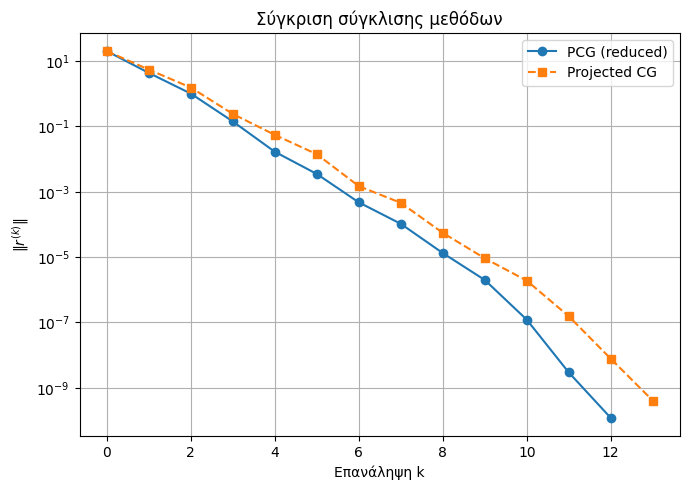

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [23]:
print("\n--- ΣΥΓΚΡΙΣΗ ΜΕΘΟΔΩΝ ---")

print("\nPCG (reduced):")
print("Επαναλήψεις:", iters)
print("||x - x*|| =", np.linalg.norm(x_sol - x_star))
print("||A x - g|| =", np.linalg.norm(A @ x_sol - g))

print("\nProjected CG:")
print("Επαναλήψεις:", len(res_hist) - 1)
print("||x - x*|| =", np.linalg.norm(x_proj - x_star))
print("||A x - g|| =", np.linalg.norm(A @ x_proj - g))
print("len(hist) =", len(hist))
print("len(res_hist) =", len(res_hist))

print("hist[:5] =", hist[:5])
print("res_hist[:5] =", res_hist[:5])

L = min(len(hist), len(res_hist))
print("Ταυτίζονται αριθμητικά;",
      np.allclose(hist[:L], res_hist[:L]))
plt.figure(figsize=(7, 5))

plt.semilogy(hist, marker='o', linestyle='-', label='PCG (reduced)')
plt.semilogy(res_hist, marker='s', linestyle='--', label='Projected CG')

plt.xlabel("Επανάληψη k")
plt.ylabel(r"$\|r^{(k)}\|$")
plt.title("Σύγκριση σύγκλισης μεθόδων")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
cond_Hred
cond_Hpre
cond_PGP
plt.figure(figsize=(6,4))



Outer 0: alpha = 1.4286e-01, προστίθεται ο περιορισμός 18.
Outer 1: alpha = -7.6282e-17, προστίθεται ο περιορισμός 19.
Outer 2: alpha = 3.6232e-02, προστίθεται ο περιορισμός 12.
Outer 3: alpha = 0.0000e+00, προστίθεται ο περιορισμός 11.
Outer 4: alpha = 1.4377e-16, προστίθεται ο περιορισμός 10.
Outer 5: alpha = 8.4741e-02, προστίθεται ο περιορισμός 7.
Outer 6: alpha = 1.5289e-01, προστίθεται ο περιορισμός 26.
Outer 7: alpha = 7.3006e-01, προστίθεται ο περιορισμός 24.
Outer 8: πλήρες βήμα alpha = 1.
Outer 9: p≈0, αφαιρείται ο περιορισμός 11.
Outer 10: πλήρες βήμα alpha = 1.
Σύγκλιση στο outer iteration 11.

ΒΑΣΙΚΑ ΧΑΡΑΚΤΗΡΙΣΤΙΚΑ
n = 120
m = 30
rank(A) = 22
Ελάχιστη ιδιοτιμή του G = 3.0010111040894643
Μέγιστη ιδιοτιμή του G = 8.998988895910538
κ₂(G) = 2.998652315430511
min(Ax0 - b) = 6.0

ΑΠΟΤΕΛΕΣΜΑΤΑ ACTIVE-SET
Αριθμός εξωτερικών επαναλήψεων = 11
Τελικό ενεργό σύνολο W = [18, 19, 12, 10, 7, 26, 24]
Μέγεθος τελικού ενεργού συνόλου = 7
Τελική τιμή f(x) = -516.9958144317287
min(Ax - b) = -

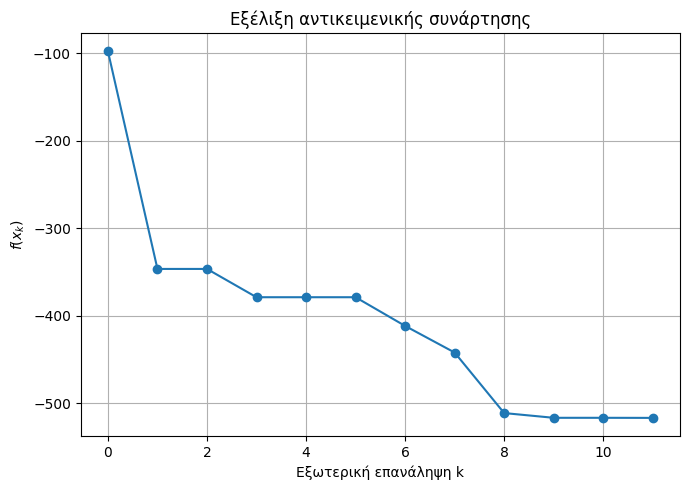

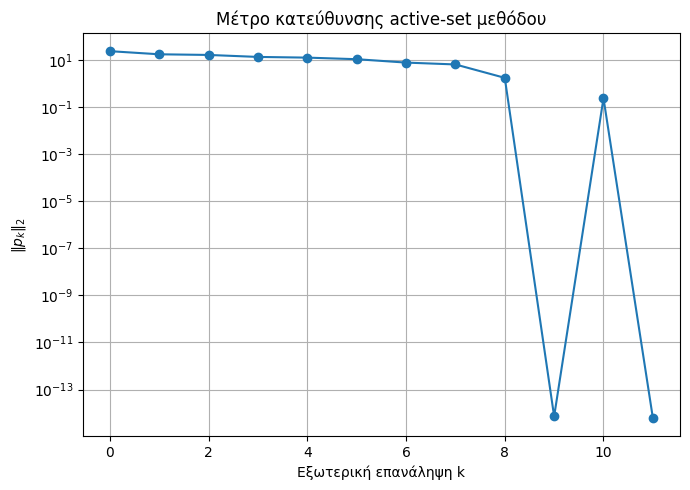

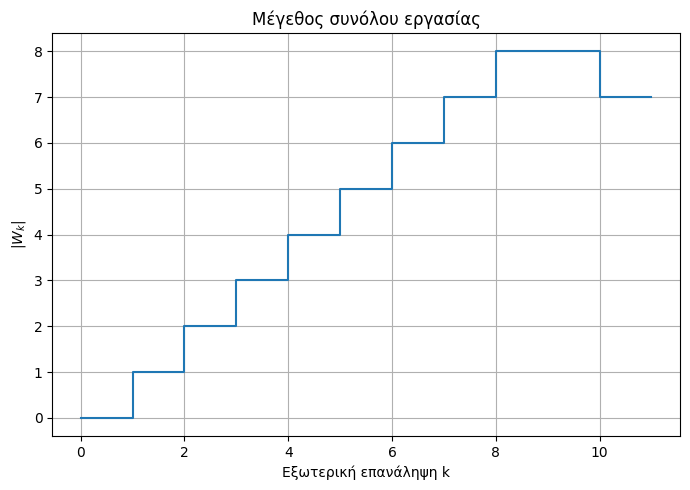

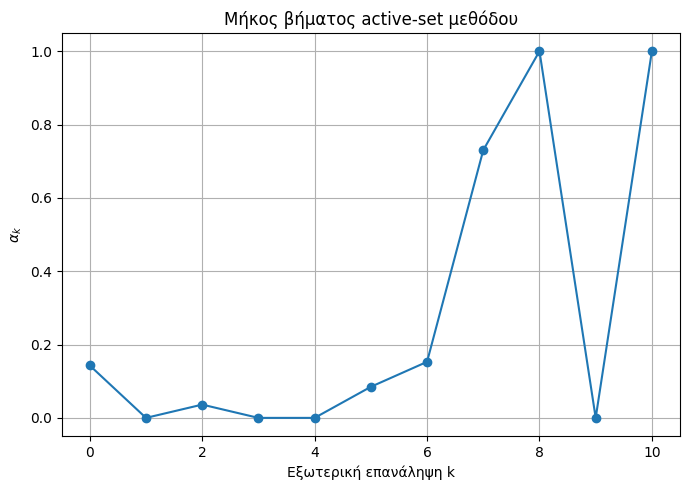

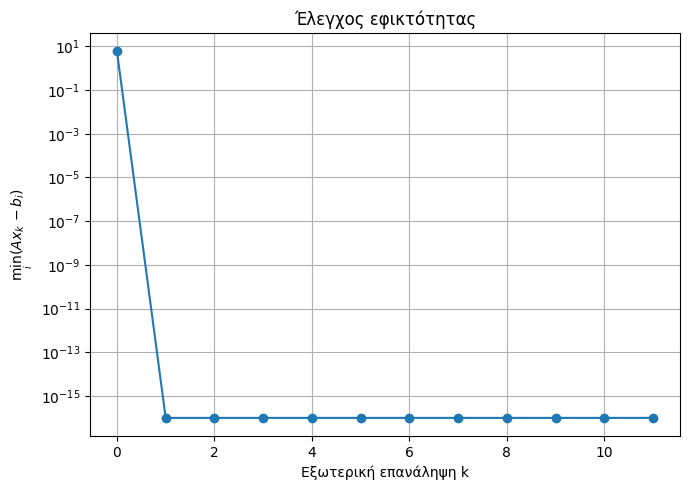

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=200)

# Διαστάσεις
n = 120
m = 30

# Πίνακας G
G = 6.0 * np.eye(n)

for i in range(n - 1):
    G[i, i + 1] = -1.5
    G[i + 1, i] = -1.5

eigvals_G = np.linalg.eigvalsh(G)
cond_G = np.linalg.cond(G, 2)

if eigvals_G.min() <= 0:
    raise ValueError("Ο πίνακας G δεν είναι θετικά ορισμένος.")

# f(x) = 1/2 x^T G x - c^T x
x_target = np.zeros(n)
x_target[:40] = 2.5
x_target[40:80] = -1.2
x_target[80:] = 3.0

c = G @ x_target

def objective(x):
    return 0.5 * x.T @ G @ x - c.T @ x

def gradient(x):
    return G @ x - c

# Περιορισμοί A x >= b
A = np.zeros((m, n))
b = np.zeros(m)

row = 0

# Επικαλυπτόμενοι upper constraints
for start in range(0, 75, 15):
    A[row, start:start+45] = -1.0
    b[row] = -25.0
    row += 1

# Επικαλυπτόμενοι lower constraints
for start in range(10, 85, 15):
    A[row, start:start+35] = 1.0
    b[row] = -5.0
    row += 1

# Τοπικοί upper constraints
for start in range(0, 100, 10):
    A[row, start:start+20] = -1.0
    b[row] = -12.0
    row += 1

# Τοπικοί lower constraints
for start in range(5, 105, 10):
    if row >= m:
        break
    A[row, start:start+15] = 1.0
    b[row] = -3.0
    row += 1

A = A[:row, :]
b = b[:row]
m = row

rank_A = np.linalg.matrix_rank(A)

# Αρχικό εφικτό σημείο
x0 = 0.2 * np.ones(n)

if np.min(A @ x0 - b) < -1e-12:
    raise ValueError("Το αρχικό σημείο x0 δεν είναι εφικτό.")

# Λύση equality-QP υποπροβλήματος με KKT
def solve_equality_qp_kkt(G, grad, Aeq):
    """
    Λύνει:
        min_p 1/2 p^T G p + grad^T p
        s.t. Aeq p = 0

    Με σύμβαση:
        L = f - lambda^T(Ax - b)

    KKT:
        Gp + grad - Aeq^T lambda = 0
        Aeq p = 0

    Δηλαδή:
        [G  -Aeq^T] [p     ] = [-grad]
        [Aeq   0  ] [lambda]   [  0  ]
    """

    n = G.shape[0]
    meq = Aeq.shape[0]

    if meq == 0:
        p = -np.linalg.solve(G, grad)
        lambda_eq = np.array([])
        return p, lambda_eq

    KKT = np.block([
        [G, -Aeq.T],
        [Aeq, np.zeros((meq, meq))]
    ])

    rhs = np.concatenate([-grad, np.zeros(meq)])
    sol = np.linalg.solve(KKT, rhs)

    p = sol[:n]
    lambda_eq = sol[n:]

    return p, lambda_eq


# Active-set μέθοδος
def active_set_qp_kkt(G, c, A, b, x0, tol=1e-10, max_outer=100):
    x = x0.copy()
    m, n = A.shape

    W = []

    obj_hist = [objective(x)]
    p_norm_hist = []
    working_size_hist = [len(W)]
    alpha_hist = []
    min_slack_hist = [np.min(A @ x - b)]
    active_sets_hist = [W.copy()]

    for k in range(max_outer):

        grad = gradient(x)

        Aeq = A[W, :] if len(W) > 0 else np.zeros((0, n))

        p, lambda_W = solve_equality_qp_kkt(G, grad, Aeq)

        p_norm = np.linalg.norm(p)
        p_norm_hist.append(p_norm)

        # Αν p ≈ 0, έλεγχος πολλαπλασιαστών
        if p_norm < tol:

            if len(W) == 0:
                print(f"Outer {k}: p≈0 και W κενό. Τερματισμός.")
                break

            Aeq = A[W, :]

            try:
                lambdas_W = np.linalg.solve(Aeq @ Aeq.T, Aeq @ grad)
            except np.linalg.LinAlgError:
                lambdas_W = np.linalg.lstsq(Aeq @ Aeq.T, Aeq @ grad, rcond=None)[0]

            min_lambda = np.min(lambdas_W)

            # Για Ax >= b και L = f - lambda^T(Ax-b), πρέπει lambda >= 0
            if min_lambda >= -tol:
                print(f"Σύγκλιση στο outer iteration {k}.")
                return (
                    x, W, obj_hist, p_norm_hist,
                    working_size_hist, alpha_hist,
                    min_slack_hist, active_sets_hist
                )

            else:
                idx_remove_local = np.argmin(lambdas_W)
                removed_constraint = W[idx_remove_local]
                W.pop(idx_remove_local)

                print(f"Outer {k}: p≈0, αφαιρείται ο περιορισμός {removed_constraint}.")

                obj_hist.append(objective(x))
                alpha_hist.append(0.0)
                working_size_hist.append(len(W))
                min_slack_hist.append(np.min(A @ x - b))
                active_sets_hist.append(W.copy())
                continue

        # Μέγιστο επιτρεπτό βήμα
        alpha = 1.0
        blocking_constraint = None

        for i in range(m):

            if i in W:
                continue

            aip = A[i] @ p

            # Για Ax >= b, αν aip < 0 ο περιορισμός μειώνεται
            if aip < -1e-14:
                slack_i = A[i] @ x - b[i]
                alpha_i = slack_i / (-aip)

                if alpha_i < alpha:
                    alpha = alpha_i
                    blocking_constraint = i

        # Ενημέρωση
        x = x + alpha * p

        if blocking_constraint is not None and alpha < 1.0 - 1e-12:
            W.append(blocking_constraint)
            print(f"Outer {k}: alpha = {alpha:.4e}, προστίθεται ο περιορισμός {blocking_constraint}.")
        else:
            print(f"Outer {k}: πλήρες βήμα alpha = 1.")

        obj_hist.append(objective(x))
        alpha_hist.append(alpha)
        working_size_hist.append(len(W))
        min_slack_hist.append(np.min(A @ x - b))
        active_sets_hist.append(W.copy())

    return (
        x, W, obj_hist, p_norm_hist,
        working_size_hist, alpha_hist,
        min_slack_hist, active_sets_hist
    )


(
    x_sol, W_final, obj_hist, p_norm_hist,
    working_size_hist, alpha_hist, min_slack_hist, active_sets_hist
) = active_set_qp_kkt(G, c, A, b, x0, tol=1e-10, max_outer=100)


# Τελικοί έλεγχοι
grad_sol = gradient(x_sol)
slacks = A @ x_sol - b

if len(W_final) > 0:
    Aeq_final = A[W_final, :]


    try:
        lambda_final = np.linalg.solve(Aeq_final @ Aeq_final.T, Aeq_final @ grad_sol)
    except np.linalg.LinAlgError:
        lambda_final = np.linalg.lstsq(Aeq_final @ Aeq_final.T, Aeq_final @ grad_sol, rcond=None)[0]

    stationarity = grad_sol - Aeq_final.T @ lambda_final
    stationarity_norm = np.linalg.norm(stationarity)

else:
    lambda_final = np.array([])
    stationarity_norm = np.linalg.norm(grad_sol)

print("\n==============================")
print("ΒΑΣΙΚΑ ΧΑΡΑΚΤΗΡΙΣΤΙΚΑ")
print("==============================")
print("n =", n)
print("m =", m)
print("rank(A) =", rank_A)
print("Ελάχιστη ιδιοτιμή του G =", eigvals_G.min())
print("Μέγιστη ιδιοτιμή του G =", eigvals_G.max())
print("κ₂(G) =", cond_G)
print("min(Ax0 - b) =", np.min(A @ x0 - b))

print("\n==============================")
print("ΑΠΟΤΕΛΕΣΜΑΤΑ ACTIVE-SET")
print("==============================")
print("Αριθμός εξωτερικών επαναλήψεων =", len(obj_hist) - 1)
print("Τελικό ενεργό σύνολο W =", W_final)
print("Μέγεθος τελικού ενεργού συνόλου =", len(W_final))
print("Τελική τιμή f(x) =", objective(x_sol))
print("min(Ax - b) =", np.min(slacks))
print("||stationarity||_2 =", stationarity_norm)
print("Πολλαπλασιαστές ενεργών περιορισμών λ =", lambda_final)
print("min(λ) =", np.min(lambda_final) if len(lambda_final) > 0 else None)

print("\nΤιμές Ax - b:")
print(slacks)


# Γραφήματα
plt.figure(figsize=(7, 5))
plt.plot(range(len(obj_hist)), obj_hist, marker='o')
plt.xlabel("Εξωτερική επανάληψη k")
plt.ylabel(r"$f(x_k)$")
plt.title("Εξέλιξη αντικειμενικής συνάρτησης")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(range(len(p_norm_hist)), p_norm_hist, marker='o')
plt.xlabel("Εξωτερική επανάληψη k")
plt.ylabel(r"$\|p_k\|_2$")
plt.title("Μέτρο κατεύθυνσης active-set μεθόδου")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.step(range(len(working_size_hist)), working_size_hist, where='post')
plt.xlabel("Εξωτερική επανάληψη k")
plt.ylabel(r"$|W_k|$")
plt.title("Μέγεθος συνόλου εργασίας")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(range(len(alpha_hist)), alpha_hist, marker='o')
plt.xlabel("Εξωτερική επανάληψη k")
plt.ylabel(r"$\alpha_k$")
plt.title("Μήκος βήματος active-set μεθόδου")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(
    range(len(min_slack_hist)),
    np.maximum(min_slack_hist, 1e-16),
    marker='o'
)
plt.xlabel("Εξωτερική επανάληψη k")
plt.ylabel(r"$\min_i(Ax_k-b_i)$")
plt.title("Έλεγχος εφικτότητας")
plt.grid(True)
plt.tight_layout()
plt.show()

Σύγκλιση στο iteration 8.

ΒΑΣΙΚΑ ΧΑΡΑΚΤΗΡΙΣΤΙΚΑ
n = 120
m = 30
rank(A) = 22
Ελάχιστη ιδιοτιμή του G = 3.0010111040894643
Μέγιστη ιδιοτιμή του G = 8.998988895910538
κ₂(G) = 2.998652315430511

ΑΠΟΤΕΛΕΣΜΑΤΑ PRIMAL-DUAL INTERIOR-POINT
Αριθμός επαναλήψεων = 8
Τελική τιμή f(x) = -516.9958144312354
||r_p||_2 = 2.4235959805057873e-12
||r_d||_2 = 6.588052121166142e-11
mu = 2.1359809169634585e-11
min(y) = 1.4203361772586661e-13
min(lambda) = 6.793879869525216e-14
min(Ax - b) = -2.9753977059954195e-13
Περιορισμοί με Ax-b < 1e-7: [ 7 10 12 18 19 24 26]
Πλήθος σχεδόν ενεργών περιορισμών = 7

Τιμές Ax - b:
[ 3.092  15.2705 23.5843 18.4135 10.7467 20.5529  9.1149 -0.     13.5815 19.7007  0.      0.7708  0.      8.6827 17.092  14.4411 16.1395  1.966   0.      0.     11.4692 11.4058 12.2069  3.525
  0.      1.5475  0.     12.4945  7.6064 15.8648]


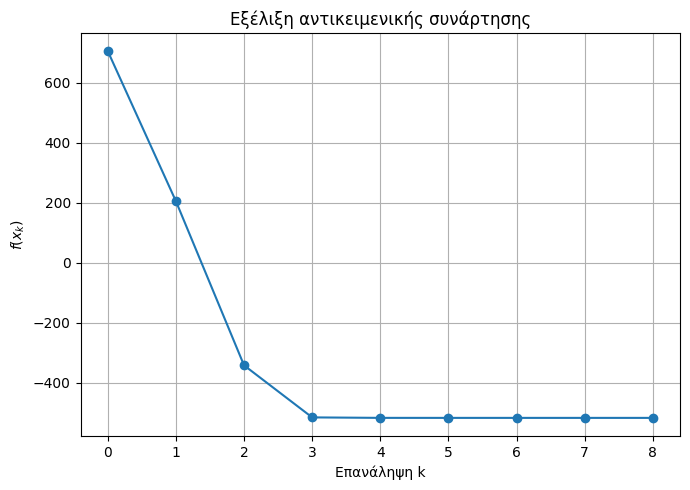

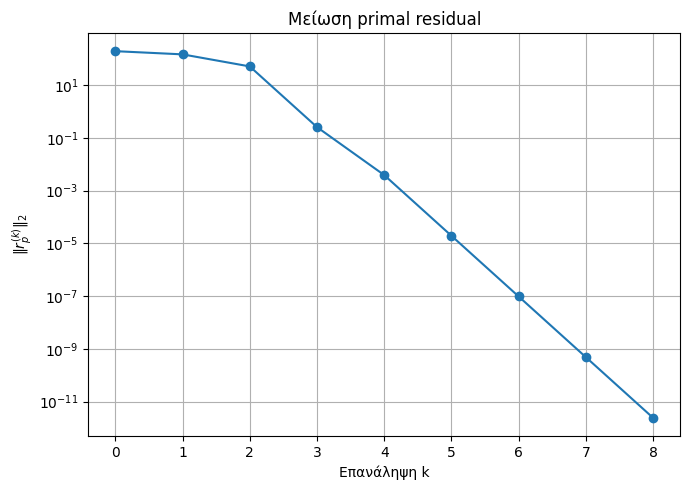

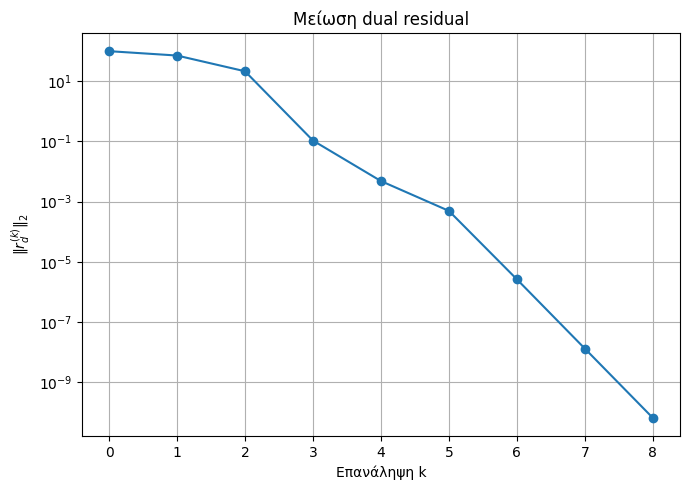

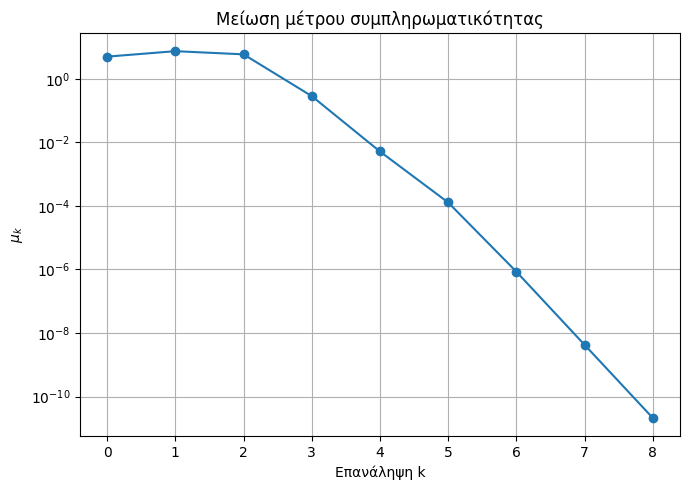

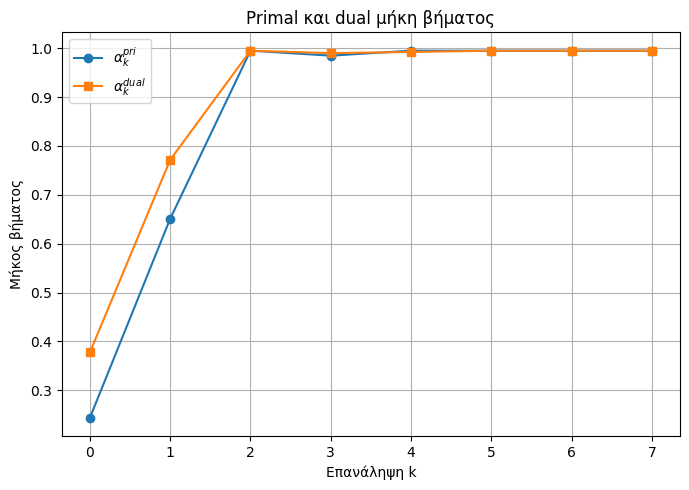

In [27]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=200)

#Διαστάσεις
n = 120
m = 30

#SPD πίνακας G
G = 6.0 * np.eye(n)

for i in range(n - 1):
    G[i, i + 1] = -1.5
    G[i + 1, i] = -1.5

eigvals_G = np.linalg.eigvalsh(G)
cond_G = np.linalg.cond(G, 2)

if eigvals_G.min() <= 0:
    raise ValueError("Ο πίνακας G δεν είναι θετικά ορισμένος.")


#Αντικειμενική f(x)
x_target = np.zeros(n)
x_target[:40] = 2.5
x_target[40:80] = -1.2
x_target[80:] = 3.0

c = G @ x_target

def objective(x):
    return 0.5 * x.T @ G @ x - c.T @ x

#Περιορισμοί A x >= b
A = np.zeros((m, n))
b = np.zeros(m)

row = 0

# Επικαλυπτόμενοι upper constraints
for start in range(0, 75, 15):
    A[row, start:start + 45] = -1.0
    b[row] = -25.0
    row += 1

# Επικαλυπτόμενοι lower constraints
for start in range(10, 85, 15):
    A[row, start:start + 35] = 1.0
    b[row] = -5.0
    row += 1

#Τοπικοί upper constraints
for start in range(0, 100, 10):
    A[row, start:start + 20] = -1.0
    b[row] = -12.0
    row += 1

#Τοπικοί lower constraints
for start in range(5, 105, 10):
    if row >= m:
        break
    A[row, start:start + 15] = 1.0
    b[row] = -3.0
    row += 1

A = A[:row, :]
b = b[:row]
m = row
rank_A = np.linalg.matrix_rank(A)


#Βοηθητική συνάρτηση για μήκος βήματος
def alpha_max_positive(v, dv):
    idx = dv < 0
    if np.any(idx):
        return min(1.0, np.min(-v[idx] / dv[idx]))
    return 1.0

#Primal-dual predictor-corrector μέθοδος
def primal_dual_predictor_corrector(
    G, c, A, b,
    tol=1e-10,
    maxit=80,
    tau=0.995
):
    n = G.shape[0]
    m = A.shape[0]


    x = -1.0 * np.ones(n)
    y = 5.0 * np.ones(m)
    lam = 1.0 * np.ones(m)

    obj_hist = []
    primal_hist = []
    dual_hist = []
    mu_hist = []
    alpha_pri_hist = []
    alpha_dual_hist = []

    for k in range(maxit):

        Y = np.diag(y)
        Lam = np.diag(lam)

        #KKT residuals
        r_d = G @ x - c - A.T @ lam
        r_p = A @ x - y - b
        mu = (y @ lam) / m

        obj_hist.append(objective(x))
        primal_hist.append(np.linalg.norm(r_p))
        dual_hist.append(np.linalg.norm(r_d))
        mu_hist.append(mu)

        if max(np.linalg.norm(r_p), np.linalg.norm(r_d), mu) < tol:
            print(f"Σύγκλιση στο iteration {k}.")
            break

        KKT = np.block([
            [G,                np.zeros((n, m)),   -A.T],
            [A,               -np.eye(m),           np.zeros((m, m))],
            [np.zeros((m, n)), Lam,                 Y]
        ])


        #Affine-scaling predictor step, sigma = 0
        rhs_aff = np.concatenate([
            -r_d,
            -r_p,
            -y * lam
        ])

        sol_aff = np.linalg.solve(KKT, rhs_aff)

        dx_aff = sol_aff[:n]
        dy_aff = sol_aff[n:n+m]
        dlam_aff = sol_aff[n+m:]

        alpha_aff_pri = alpha_max_positive(y, dy_aff)
        alpha_aff_dual = alpha_max_positive(lam, dlam_aff)

        mu_aff = (
            (y + alpha_aff_pri * dy_aff).T
            @
            (lam + alpha_aff_dual * dlam_aff)
        ) / m

        sigma = (mu_aff / mu) ** 3
        sigma = min(max(sigma, 0.0), 1.0)


        # Corrector step

        rhs_corr = np.concatenate([
            -r_d,
            -r_p,
            -y * lam - dy_aff * dlam_aff + sigma * mu * np.ones(m)
        ])

        sol_corr = np.linalg.solve(KKT, rhs_corr)

        dx = sol_corr[:n]
        dy = sol_corr[n:n+m]
        dlam = sol_corr[n+m:]

        alpha_pri = alpha_max_positive(y, dy)
        alpha_dual = alpha_max_positive(lam, dlam)

        alpha_pri = min(1.0, tau * alpha_pri)
        alpha_dual = min(1.0, tau * alpha_dual)

        x = x + alpha_pri * dx
        y = y + alpha_pri * dy
        lam = lam + alpha_dual * dlam

        alpha_pri_hist.append(alpha_pri)
        alpha_dual_hist.append(alpha_dual)

    return (
        x, y, lam,
        obj_hist,
        primal_hist,
        dual_hist,
        mu_hist,
        alpha_pri_hist,
        alpha_dual_hist
    )


(
    x_ip, y_ip, lambda_ip,
    obj_hist,
    primal_hist,
    dual_hist,
    mu_hist,
    alpha_pri_hist,
    alpha_dual_hist
) = primal_dual_predictor_corrector(
    G, c, A, b,
    tol=1e-10,
    maxit=80,
    tau=0.995
)


# Τελικοί έλεγχοι=
r_d_final = G @ x_ip - c - A.T @ lambda_ip
r_p_final = A @ x_ip - y_ip - b
mu_final = (y_ip @ lambda_ip) / m
slacks = A @ x_ip - b

active_constraints = np.where(slacks < 1e-7)[0]

print("\n==============================")
print("ΒΑΣΙΚΑ ΧΑΡΑΚΤΗΡΙΣΤΙΚΑ")
print("==============================")
print("n =", n)
print("m =", m)
print("rank(A) =", rank_A)
print("Ελάχιστη ιδιοτιμή του G =", eigvals_G.min())
print("Μέγιστη ιδιοτιμή του G =", eigvals_G.max())
print("κ₂(G) =", cond_G)

print("\n==============================")
print("ΑΠΟΤΕΛΕΣΜΑΤΑ PRIMAL-DUAL INTERIOR-POINT")
print("==============================")
print("Αριθμός επαναλήψεων =", len(obj_hist) - 1)
print("Τελική τιμή f(x) =", objective(x_ip))
print("||r_p||_2 =", np.linalg.norm(r_p_final))
print("||r_d||_2 =", np.linalg.norm(r_d_final))
print("mu =", mu_final)
print("min(y) =", np.min(y_ip))
print("min(lambda) =", np.min(lambda_ip))
print("min(Ax - b) =", np.min(slacks))
print("Περιορισμοί με Ax-b < 1e-7:", active_constraints)
print("Πλήθος σχεδόν ενεργών περιορισμών =", len(active_constraints))

print("\nΤιμές Ax - b:")
print(slacks)



plt.figure(figsize=(7, 5))
plt.plot(range(len(obj_hist)), obj_hist, marker='o')
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$f(x_k)$")
plt.title("Εξέλιξη αντικειμενικής συνάρτησης")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(range(len(primal_hist)), primal_hist, marker='o')
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$\|r_p^{(k)}\|_2$")
plt.title("Μείωση primal residual")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(range(len(dual_hist)), dual_hist, marker='o')
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$\|r_d^{(k)}\|_2$")
plt.title("Μείωση dual residual")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(range(len(mu_hist)), mu_hist, marker='o')
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$\mu_k$")
plt.title("Μείωση μέτρου συμπληρωματικότητας")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(range(len(alpha_pri_hist)), alpha_pri_hist, marker='o', label=r"$\alpha_k^{pri}$")
plt.plot(range(len(alpha_dual_hist)), alpha_dual_hist, marker='s', label=r"$\alpha_k^{dual}$")
plt.xlabel("Επανάληψη k")
plt.ylabel("Μήκος βήματος")
plt.title("Primal και dual μήκη βήματος")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Exact f(x*) = -59.20000000000001
||A x_star - g|| = 0.0
||G x_star - b - A.T lambda_star|| = 1.538370149106851e-15

QUADRATIC PENALTY METHOD

Outer Iteration 1
mu = 1.0000e+00
||xk-x*||      = 7.3544e-01
||Axk-g||      = 2.3870e+00
|f-f*|         = 8.1302e+00
cond(H_mu)     = 4.8876e+00

Outer Iteration 2
mu = 1.0000e+01
||xk-x*||      = 1.3116e-01
||Axk-g||      = 4.0917e-01
|f-f*|         = 1.7516e+00
cond(H_mu)     = 2.9579e+01

Outer Iteration 3
mu = 1.0000e+02
||xk-x*||      = 1.4373e-02
||Axk-g||      = 4.4303e-02
|f-f*|         = 1.9720e-01
cond(H_mu)     = 2.7766e+02

Outer Iteration 4
mu = 1.0000e+03
||xk-x*||      = 1.4516e-03
||Axk-g||      = 4.4679e-03
|f-f*|         = 1.9972e-02
cond(H_mu)     = 2.7586e+03

Outer Iteration 5
mu = 1.0000e+04
||xk-x*||      = 1.4530e-04
||Axk-g||      = 4.4717e-04
|f-f*|         = 1.9997e-03
cond(H_mu)     = 2.7568e+04

Outer Iteration 6
mu = 1.0000e+05
||xk-x*||      = 1.4532e-05
||Axk-g||      = 4.4721e-05
|f-f*|         = 2.0000e-04
cond(

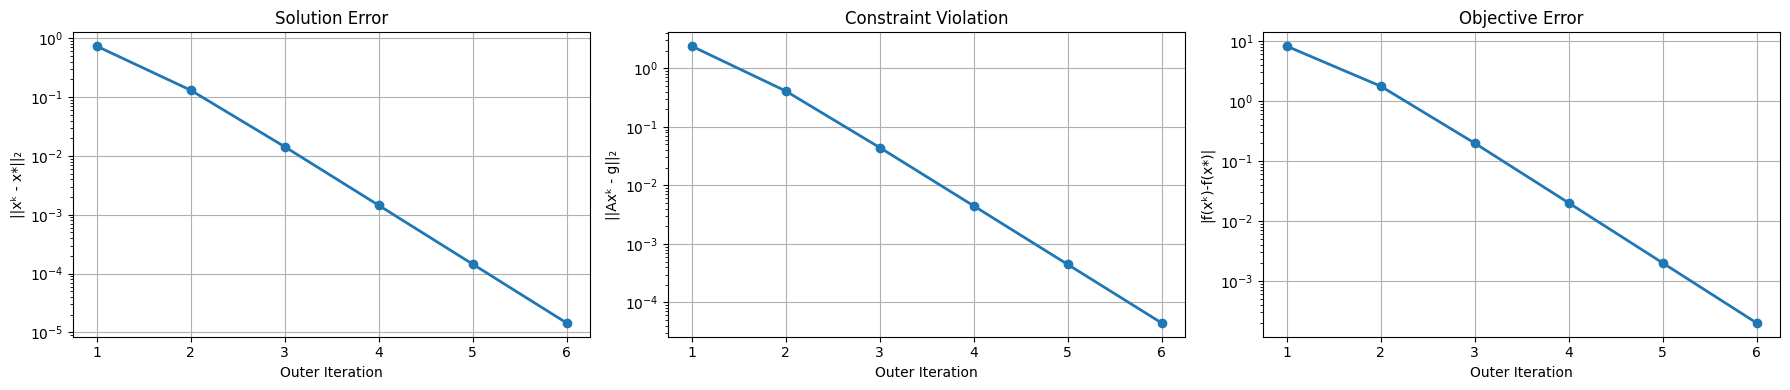

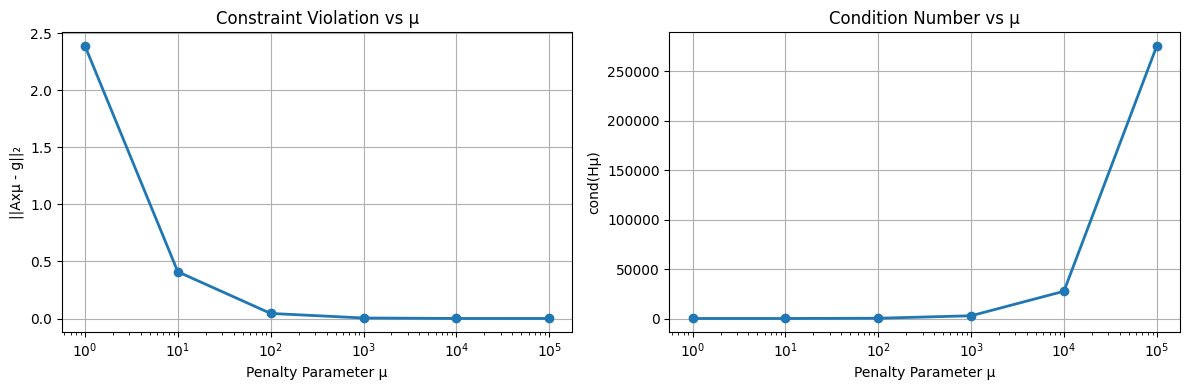


FINAL RESULTS

Final solution error    : 1.4532e-05
Final feasibility error : 4.4721e-05
Final objective error   : 2.0000e-04
Final condition number  : 2.7566e+05

--- ΕΛΕΓΧΟΣ ΤΕΛΙΚΗΣ ΤΙΜΗΣ QUADRATIC PENALTY ---
Final f(x_QP)          : -5.920019999716e+01
Exact f(x*)            : -5.920000000000e+01
|f(x_QP)-f(x*)|        : 1.999971583047e-04
||A x_QP - g||_2       : 4.472093593817e-05
||x_QP - x*||_2        : 1.453181798960e-05


In [28]:
import numpy as np
import matplotlib.pyplot as plt


#Διαστασεις
n = 24
m = 8

#Πίνακας G
G = np.zeros((n, n))

main_diag = 8.0
off1 = -1.2
off2 = -0.5
off3 = -0.2

for i in range(n):
    G[i, i] = main_diag

for i in range(n - 1):
    G[i, i + 1] = off1
    G[i + 1, i] = off1

for i in range(n - 2):
    G[i, i + 2] = off2
    G[i + 2, i] = off2

for i in range(n - 3):
    G[i, i + 3] = off3
    G[i + 3, i] = off3


# Πίνακας A
A = np.array([
    [ 2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.]
], dtype=float)



x_star = np.ones(n)

lambda_star = np.array(
    [1, -1, 2, -2, 1, -1, 2, -2],
    dtype=float
)

g = A @ x_star
b = G @ x_star - A.T @ lambda_star
f_star = 0.5 * x_star.T @ G @ x_star - b.T @ x_star
print("Exact f(x*) =", f_star)
print("||A x_star - g|| =", np.linalg.norm(A @ x_star - g))
print("||G x_star - b - A.T lambda_star|| =",
      np.linalg.norm(G @ x_star - b - A.T @ lambda_star))


#Αρχικό εφικτό σημείο
x0 = A.T @ np.linalg.solve(A @ A.T, g)


#Παράμετροι ποινής
mu0 = 1.0
growth_factor = 10.0
outer_iterations = 6


#ακριβής τιμή της f
f_star = 0.5 * x_star.T @ G @ x_star - b.T @ x_star

iteration_axis = []
mu_axis = []

solution_errors = []
constraint_errors = []
objective_errors = []

mu_constraint_errors = []
mu_condition_numbers = []

#Αρχικό σημείο
xk = x0.copy()
mu = mu0

#Quadratic Penalty Method
print("\n===================================")
print("QUADRATIC PENALTY METHOD")
print("===================================")

for k in range(outer_iterations):

    print(f"\nOuter Iteration {k+1}")
    print(f"mu = {mu:.4e}")


    # Penalty Hessian

    H_mu = G + mu * (A.T @ A)


    # RHS

    rhs = b + mu * A.T @ g


    #Λύση υπορποβλήματος χωρίς περιορισμούς

    xk = np.linalg.solve(H_mu, rhs)


    #Μετρικές
    f_val = 0.5 * xk.T @ G @ xk - b.T @ xk

    solution_error = np.linalg.norm(xk - x_star)

    constraint_violation = np.linalg.norm(A @ xk - g)

    objective_error = abs(f_val - f_star)

    cond_number = np.linalg.cond(H_mu)


    #Store for iteration plots
    iteration_axis.append(k + 1)

    solution_errors.append(solution_error)
    constraint_errors.append(constraint_violation)
    objective_errors.append(objective_error)


    #Store for mu plots
    mu_axis.append(mu)

    mu_constraint_errors.append(constraint_violation)
    mu_condition_numbers.append(cond_number)


    print(f"||xk-x*||      = {solution_error:.4e}")
    print(f"||Axk-g||      = {constraint_violation:.4e}")
    print(f"|f-f*|         = {objective_error:.4e}")
    print(f"cond(H_mu)     = {cond_number:.4e}")


    mu *= growth_factor




fig, axes = plt.subplots(1, 3, figsize=(18, 4))


#Solution Error
axes[0].semilogy(
    iteration_axis,
    solution_errors,
    marker='o',
    linewidth=2
)

axes[0].set_xlabel("Outer Iteration")
axes[0].set_ylabel("||xᵏ - x*||₂")
axes[0].set_title("Solution Error")
axes[0].grid(True)

#Constraint Violation
axes[1].semilogy(
    iteration_axis,
    constraint_errors,
    marker='o',
    linewidth=2
)

axes[1].set_xlabel("Outer Iteration")
axes[1].set_ylabel("||Axᵏ - g||₂")
axes[1].set_title("Constraint Violation")
axes[1].grid(True)

#Objective Error
axes[2].semilogy(
    iteration_axis,
    objective_errors,
    marker='o',
    linewidth=2
)

axes[2].set_xlabel("Outer Iteration")
axes[2].set_ylabel("|f(xᵏ)-f(x*)|")
axes[2].set_title("Objective Error")
axes[2].grid(True)

plt.tight_layout()
plt.show()




fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Feasibility vs mu
axes[0].semilogx(
    mu_axis,
    mu_constraint_errors,
    marker='o',
    linewidth=2
)

axes[0].set_xlabel("Penalty Parameter μ")
axes[0].set_ylabel("||Axμ - g||₂")
axes[0].set_title("Constraint Violation vs μ")
axes[0].grid(True)

#Conditioning vs mu
axes[1].semilogx(
    mu_axis,
    mu_condition_numbers,
    marker='o',
    linewidth=2
)

axes[1].set_xlabel("Penalty Parameter μ")
axes[1].set_ylabel("cond(Hμ)")
axes[1].set_title("Condition Number vs μ")
axes[1].grid(True)

plt.tight_layout()
plt.show()


print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"\nFinal solution error    : {solution_errors[-1]:.4e}")
print(f"Final feasibility error : {constraint_errors[-1]:.4e}")
print(f"Final objective error   : {objective_errors[-1]:.4e}")
print(f"Final condition number  : {mu_condition_numbers[-1]:.4e}")
print("\n--- ΕΛΕΓΧΟΣ ΤΕΛΙΚΗΣ ΤΙΜΗΣ QUADRATIC PENALTY ---")
print(f"Final f(x_QP)          : {f_val:.12e}")
print(f"Exact f(x*)            : {f_star:.12e}")
print(f"|f(x_QP)-f(x*)|        : {abs(f_val - f_star):.12e}")
print(f"||A x_QP - g||_2       : {np.linalg.norm(A @ xk - g):.12e}")
print(f"||x_QP - x*||_2        : {np.linalg.norm(xk - x_star):.12e}")


EXACT L1 PENALTY METHOD

mu* = ||lambda*||_inf = 2.0000e+00
f(x*) = -59.200000000000

Outer Iteration 1
mu = 2.0000e-01
Inner iterations = 26
||xk-x*||        = 1.4390e+00
||Axk-g||        = 4.7718e+00
|f-f*|           = 1.1492e+01
f(xk)            = -70.691625828119
phi1(xk;mu)      = -6.8297e+01

Outer Iteration 2
mu = 1.0000e+00
Inner iterations = 19
||xk-x*||        = 7.2105e-01
||Axk-g||        = 2.3502e+00
|f-f*|           = 7.5793e+00
f(xk)            = -66.779338035810
phi1(xk;mu)      = -6.1489e+01

Outer Iteration 3
mu = 2.0000e+00
Inner iterations = 35
||xk-x*||        = 7.1352e-08
||Axk-g||        = 1.8116e-07
|f-f*|           = 6.3846e-07
f(xk)            = -59.200000638461
phi1(xk;mu)      = -5.9200e+01

Outer Iteration 4
mu = 4.0000e+00
Inner iterations = 16
||xk-x*||        = 3.2989e-08
||Axk-g||        = 5.0065e-13
|f-f*|           = 2.1529e-12
f(xk)            = -59.200000000002
phi1(xk;mu)      = -5.9200e+01

Outer Iteration 5
mu = 1.0000e+01
Inner iterations = 9
||

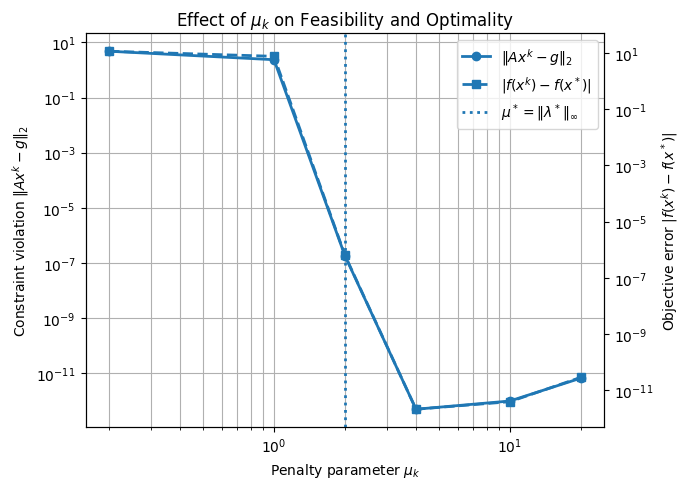

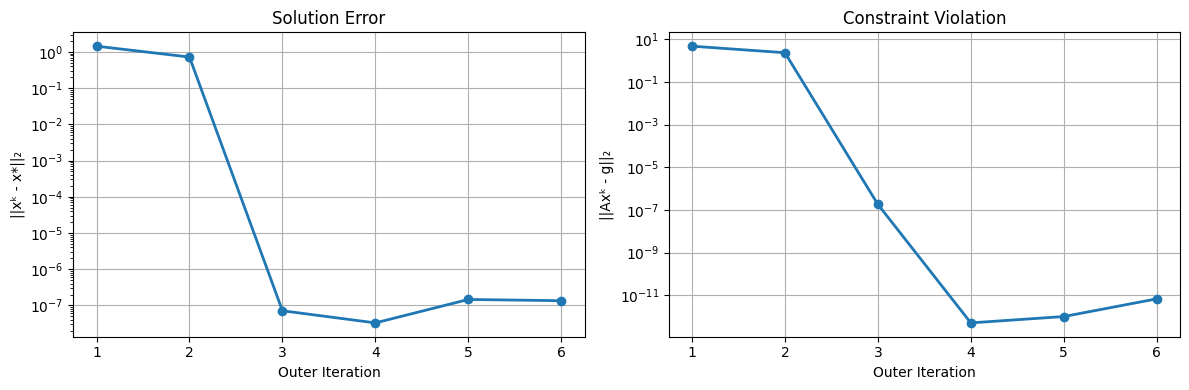

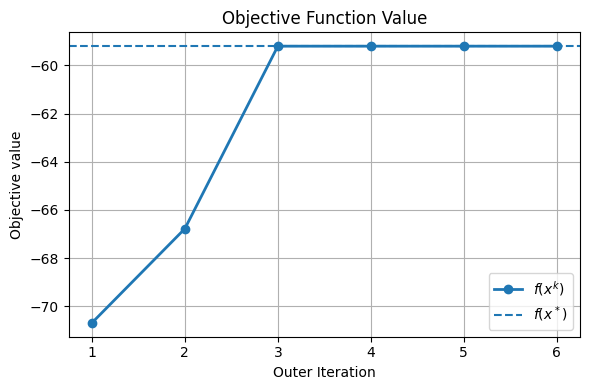

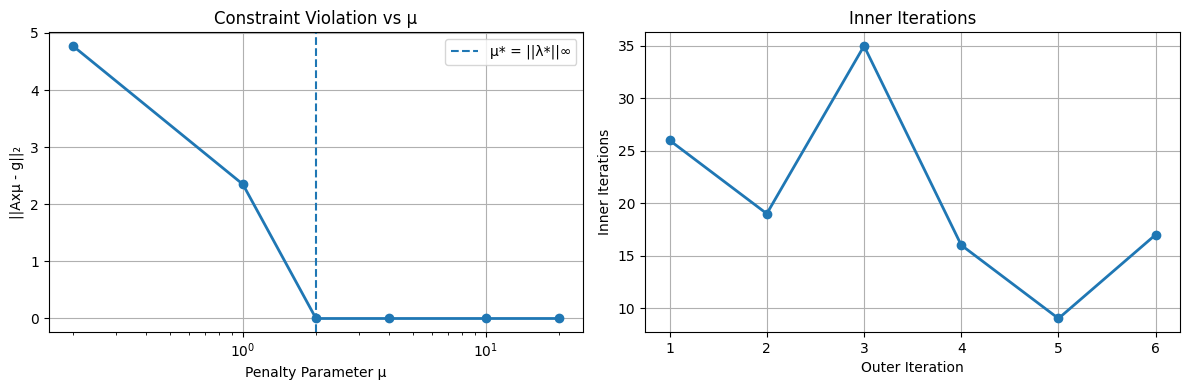


FINAL RESULTS
mu*                    : 2.0000e+00
Final mu               : 2.0000e+01
Final f(x_L1)          : -59.200000000029
Exact f(x*)            : -59.200000000000
Final solution error   : 1.3506e-07
Final feasibility error: 6.7207e-12
Final objective error  : 2.9281e-11
KKT residual           : 1.2168e-06


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Διαστάσεις
n = 24
m = 8

# Πίνακας G
G = np.zeros((n, n))

for i in range(n):
    G[i, i] = 8.0

for i in range(n - 1):
    G[i, i + 1] = -1.2
    G[i + 1, i] = -1.2

for i in range(n - 2):
    G[i, i + 2] = -0.5
    G[i + 2, i] = -0.5

for i in range(n - 3):
    G[i, i + 3] = -0.2
    G[i + 3, i] = -0.2


# Πίνακας A
A = np.array([
    [ 2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.]
], dtype=float)

x_star = np.ones(n)

lambda_star = np.array(
    [1, -1, 2, -2, 1, -1, 2, -2],
    dtype=float
)

g = A @ x_star
b = G @ x_star - A.T @ lambda_star

mu_star = np.linalg.norm(lambda_star, ord=np.inf)


# Εφικτό αρχικό σημείο
x0 = A.T @ np.linalg.solve(A @ A.T, g)


# Αντικειμενική συνάρτηση
def f(x):
    return 0.5 * x.T @ G @ x - b.T @ x


def phi_l1(x, mu):
    return f(x) + mu * np.linalg.norm(A @ x - g, ord=1)


f_star = f(x_star)


def solve_l1_penalty_epigraph(x_start, mu):

    r0 = A @ x_start - g
    t0 = np.abs(r0) + 1e-6
    z0 = np.concatenate([x_start, t0])

    def objective(z):
        x = z[:n]
        t = z[n:]
        return f(x) + mu * np.sum(t)

    def gradient(z):
        x = z[:n]
        grad_x = G @ x - b
        grad_t = mu * np.ones(m)
        return np.concatenate([grad_x, grad_t])

    constraints = []

    for i in range(m):
        constraints.append({
            "type": "ineq",
            "fun": lambda z, i=i: z[n + i] - (A @ z[:n] - g)[i]
        })

    for i in range(m):
        constraints.append({
            "type": "ineq",
            "fun": lambda z, i=i: z[n + i] + (A @ z[:n] - g)[i]
        })

    for i in range(m):
        constraints.append({
            "type": "ineq",
            "fun": lambda z, i=i: z[n + i]
        })

    result = minimize(
        objective,
        z0,
        jac=gradient,
        method="SLSQP",
        constraints=constraints,
        options={
            "ftol": 1e-12,
            "maxiter": 1000,
            "disp": False
        }
    )

    x_new = result.x[:n]
    return x_new, result


# Παράμετροι ποινής
mu_values = [
    0.1 * mu_star,
    0.5 * mu_star,
    1.0 * mu_star,
    2.0 * mu_star,
    5.0 * mu_star,
    10.0 * mu_star
]


solution_errors = []
constraint_errors = []
objective_errors = []
phi_values = []
inner_iterations = []
objective_values = []

xk = x0.copy()

print("\n===================================")
print("EXACT L1 PENALTY METHOD")
print("===================================")
print(f"\nmu* = ||lambda*||_inf = {mu_star:.4e}")
print(f"f(x*) = {f_star:.12f}")


# Exact L1 penalty method
for k, mu in enumerate(mu_values):

    xk, result = solve_l1_penalty_epigraph(xk, mu)

    sol_error = np.linalg.norm(xk - x_star, ord=2)
    feasibility = np.linalg.norm(A @ xk - g, ord=2)
    obj_error = abs(f(xk) - f_star)
    phi_val = phi_l1(xk, mu)
    f_val = f(xk)

    objective_values.append(f_val)
    solution_errors.append(sol_error)
    constraint_errors.append(feasibility)
    objective_errors.append(obj_error)
    phi_values.append(phi_val)
    inner_iterations.append(result.nit)

    print(f"\nOuter Iteration {k + 1}")
    print(f"mu = {mu:.4e}")
    print(f"Inner iterations = {result.nit}")
    print(f"||xk-x*||        = {sol_error:.4e}")
    print(f"||Axk-g||        = {feasibility:.4e}")
    print(f"|f-f*|           = {obj_error:.4e}")
    print(f"f(xk)            = {f_val:.12f}")
    print(f"phi1(xk;mu)      = {phi_val:.4e}")



fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.set_xscale("log")
ax1.set_yscale("log")

line1 = ax1.plot(
    mu_values,
    constraint_errors,
    marker="o",
    linewidth=2,
    label=r"$\|Ax^k-g\|_2$"
)

ax1.set_xlabel(r"Penalty parameter $\mu_k$")
ax1.set_ylabel(r"Constraint violation $\|Ax^k-g\|_2$")
ax1.grid(True, which="both")

ax2 = ax1.twinx()
ax2.set_yscale("log")

line2 = ax2.plot(
    mu_values,
    objective_errors,
    marker="s",
    linewidth=2,
    linestyle="--",
    label=r"$|f(x^k)-f(x^*)|$"
)

ax2.set_ylabel(r"Objective error $|f(x^k)-f(x^*)|$")

vline = ax1.axvline(
    mu_star,
    linestyle=":",
    linewidth=2,
    label=r"$\mu^*=\|\lambda^*\|_\infty$"
)

lines = line1 + line2 + [vline]
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="upper right")

plt.title(r"Effect of $\mu_k$ on Feasibility and Optimality")
plt.tight_layout()
plt.show()


# Plots vs outer iterations
outer_iterations = np.arange(1, len(mu_values) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(outer_iterations, solution_errors, marker='o', linewidth=2)
axes[0].set_xlabel("Outer Iteration")
axes[0].set_ylabel("||xᵏ - x*||₂")
axes[0].set_title("Solution Error")
axes[0].grid(True)

axes[1].semilogy(outer_iterations, constraint_errors, marker='o', linewidth=2)
axes[1].set_xlabel("Outer Iteration")
axes[1].set_ylabel("||Axᵏ - g||₂")
axes[1].set_title("Constraint Violation")
axes[1].grid(True)

plt.tight_layout()
plt.show()


# Objective function value
plt.figure(figsize=(6, 4))

plt.plot(outer_iterations, objective_values, marker='o', linewidth=2, label=r"$f(x^k)$")
plt.axhline(f_star, linestyle="--", label=r"$f(x^*)$")

plt.xlabel("Outer Iteration")
plt.ylabel("Objective value")
plt.title("Objective Function Value")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Plots vs penalty parameter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(mu_values, constraint_errors, marker='o', linewidth=2)
axes[0].axvline(mu_star, linestyle='--', label="μ* = ||λ*||∞")
axes[0].set_xlabel("Penalty Parameter μ")
axes[0].set_ylabel("||Axμ - g||₂")
axes[0].set_title("Constraint Violation vs μ")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(outer_iterations, inner_iterations, marker='o', linewidth=2)
axes[1].set_xlabel("Outer Iteration")
axes[1].set_ylabel("Inner Iterations")
axes[1].set_title("Inner Iterations")
axes[1].grid(True)

plt.tight_layout()
plt.show()



print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"mu*                    : {mu_star:.4e}")
print(f"Final mu               : {mu_values[-1]:.4e}")
print(f"Final f(x_L1)          : {f(xk):.12f}")
print(f"Exact f(x*)            : {f_star:.12f}")
print(f"Final solution error   : {solution_errors[-1]:.4e}")
print(f"Final feasibility error: {constraint_errors[-1]:.4e}")
print(f"Final objective error  : {objective_errors[-1]:.4e}")
print(f"KKT residual           : {np.linalg.norm(G @ xk - b - A.T @ lambda_star):.4e}")

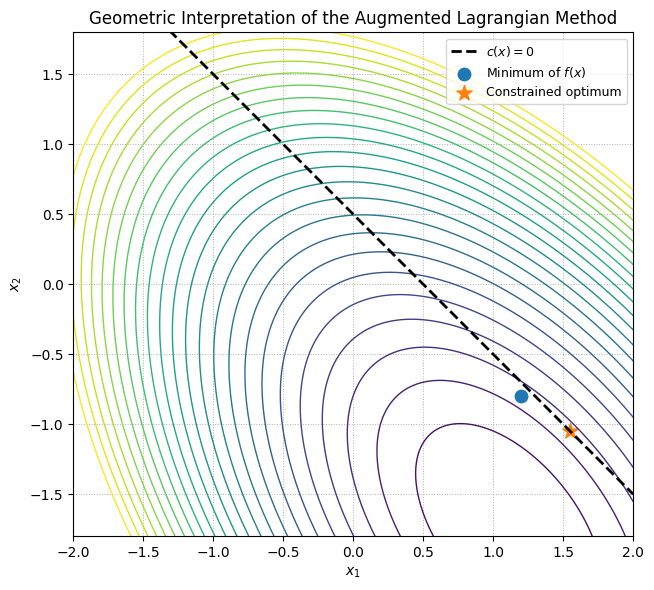

In [30]:
import numpy as np
import matplotlib.pyplot as plt

#αντικειμενική συνάρτηση
def f(x1, x2):
    return (x1 - 1.2)**2 + 0.7*(x2 + 0.8)**2 + 0.4*x1*x2

#ισοτικός περιορισμός
def c(x1, x2):
    return x1 + x2 - 0.5

#Augmented Lagrangian
def L_aug(x1, x2, lam, mu):
    return f(x1, x2) - lam*c(x1, x2) + (mu/2)*c(x1, x2)**2

#Parameters
mu = 1.0
lam = -2.0

#Grid
x1 = np.linspace(-2.0, 2.0, 500)
x2 = np.linspace(-2.0, 2.0, 500)
X1, X2 = np.meshgrid(x1, x2)

Z = L_aug(X1, X2, lam, mu)

#Feasible line: x1 + x2 = 0.5
line_x = np.linspace(-2.0, 2.0, 400)
line_y = 0.5 - line_x

x_opt = np.array([1.55, -1.05])

plt.figure(figsize=(7, 6))

#Contours only
levels = np.linspace(np.min(Z), np.percentile(Z, 85), 24)
plt.contour(X1, X2, Z, levels=levels, linewidths=1.0)

#Feasible set
plt.plot(line_x, line_y, "k--", linewidth=2.0, label=r"$c(x)=0$")

#Unconstrained minimum of f
plt.scatter(1.2, -0.8, s=80, marker="o", label="Minimum of $f(x)$")

#Constrained optimum
plt.scatter(x_opt[0], x_opt[1], s=130, marker="*", label="Constrained optimum")


plt.annotate(
    "",
    xy=x_opt,
    xytext=(0.9, -1.45),

)


plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Geometric Interpretation of the Augmented Lagrangian Method")
plt.legend(fontsize=9)
plt.grid(True, linestyle=":", linewidth=0.7)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-2.0, 2.0)
plt.ylim(-1.8, 1.8)
plt.tight_layout()
plt.show()


ΑΡΧΙΚΟΙ ΕΛΕΓΧΟΙ
--------------------------------
rank(A) = 8
Ελάχιστη ιδιοτιμή του G = 4.274254643503e+00
||A x0 - g||_2 = 1.554312234475e-15
||G x* - b - A^T lambda*||_2 = 1.538370149107e-15

ΑΠΟΤΕΛΕΣΜΑΤΑ AUGMENTED LAGRANGIAN
--------------------------------
Αριθμός επαναλήψεων = 65
Τελική τιμή f(x_k)                  = -5.920000000000e+01
Βέλτιστη τιμή f(x*)                 = -5.920000000000e+01
|f(x_k)-f(x*)|                      = 6.394884621841e-13
||A x_k - g||_2                     = 4.122211893175e-13
||x_k - x*||_2                      = 1.968569126487e-13
||lambda_k - lambda*||_2            = 7.511788018860e-13
||G x_k - b - A^T lambda_k||_2      = 9.068558285047e-15
κ2(G)                               = 2.2894e+00
κ2(KKT)                             = 2.0891e+01
κ2(G + μ A^T A)                     = 4.8876e+00

Πρώτες 10 συνιστώσες του x_k:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Πρώτες 10 συνιστώσες του x_star:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Πρώτες 10 συνιστώσες του σφάλματος x

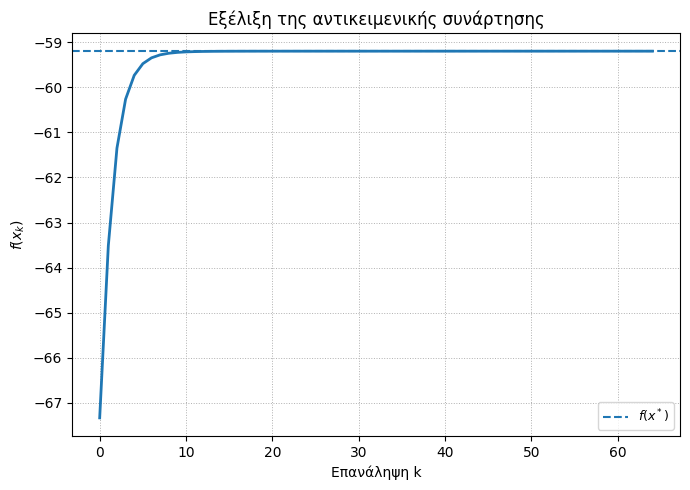

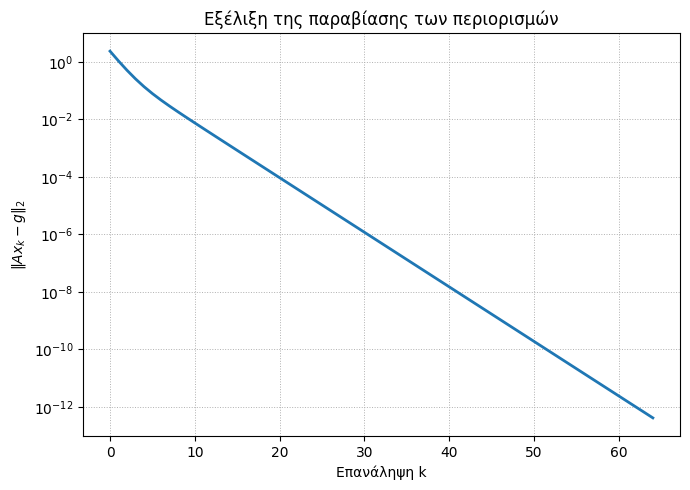

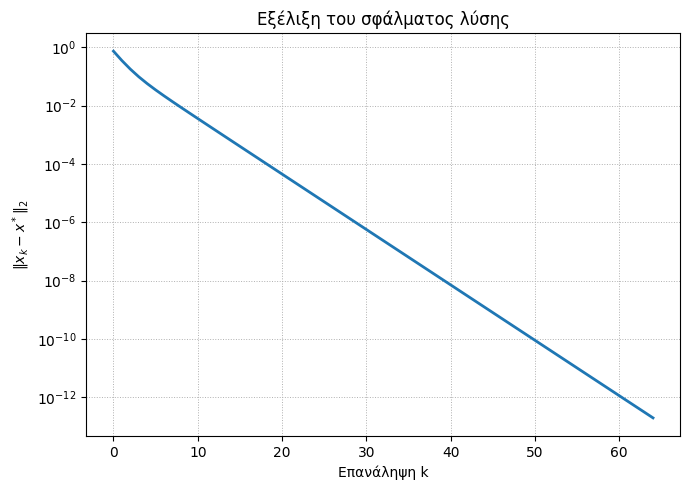

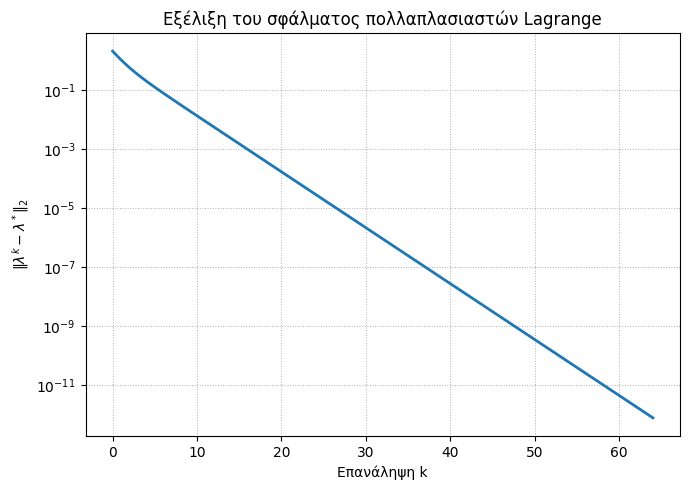

In [31]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True, linewidth=200)


# Augmented Lagrangian Method

# Διαστάσεις
n = 24
m = 8


# Πίνακας G
G = 8.0 * np.eye(n)

for i in range(n - 1):
    G[i, i + 1] = -1.2
    G[i + 1, i] = -1.2

for i in range(n - 2):
    G[i, i + 2] = -0.5
    G[i + 2, i] = -0.5

for i in range(n - 3):
    G[i, i + 3] = -0.2
    G[i + 3, i] = -0.2


# Πίνακας A
A = np.array([
    [ 2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  0.,  0.,  2., -1.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
    [ 0.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  1.,  0.,  0.,  0., -1.]
], dtype=float)


if not np.allclose(G, G.T):
    raise ValueError("Ο πίνακας G δεν είναι συμμετρικός.")

eigvals_G = np.linalg.eigvalsh(G)

if eigvals_G.min() <= 0:
    raise ValueError("Ο πίνακας G δεν είναι θετικά ορισμένος.")

rank_A = np.linalg.matrix_rank(A)

if rank_A < m:
    raise ValueError("Ο πίνακας A δεν έχει πλήρη βαθμίδα γραμμών.")


# Κατασκευή προβλήματος με γνωστή ακριβή λύση
x_star = np.ones(n)

lambda_star = np.array(
    [1., -1., 2., -2., 1., -1., 2., -2.],
    dtype=float
)

g = A @ x_star


b = G @ x_star - A.T @ lambda_star


# Αντικειμενική και υπόλοιπο περιορισμών
def objective(x):
    return 0.5 * x.T @ G @ x - b.T @ x

def residual(x):
    return A @ x - g


#αρχικό εφικτό σημείο
AAt = A @ A.T
x0 = A.T @ np.linalg.solve(AAt, g)


# Παράμετροι μεθόδου
mu = 1.0
max_iter = 100

tol_feas = 1e-12
tol_x = 1e-12
tol_lambda = 1e-12

lambda_k = np.zeros(m)
x_k = x0.copy()

obj_hist = []
feas_hist = []
xerr_hist = []
lambdaerr_hist = []
stat_hist = []


# Augmented Lagrangian Method
for k in range(max_iter):

    lhs = G + mu * (A.T @ A)
    rhs = b + A.T @ lambda_k + mu * A.T @ g

    x_k = np.linalg.solve(lhs, rhs)

    r_k = residual(x_k)

    lambda_next = lambda_k - mu * r_k

    stat_res = G @ x_k - b - A.T @ lambda_next

    obj_hist.append(objective(x_k))
    feas_hist.append(np.linalg.norm(r_k, 2))
    xerr_hist.append(np.linalg.norm(x_k - x_star, 2))
    lambdaerr_hist.append(np.linalg.norm(lambda_next - lambda_star, 2))
    stat_hist.append(np.linalg.norm(stat_res, 2))

    if (
        feas_hist[-1] < tol_feas
        and xerr_hist[-1] < tol_x
        and lambdaerr_hist[-1] < tol_lambda
    ):
        lambda_k = lambda_next
        break

    lambda_k = lambda_next


# Αποτελέσματα
iterations = len(obj_hist)
obj_star = objective(x_star)

KKT = np.block([
    [G, -A.T],
    [A, np.zeros((m, m))]
])

cond_G = np.linalg.cond(G, 2)
cond_KKT = np.linalg.cond(KKT, 2)
cond_aug = np.linalg.cond(G + mu * A.T @ A, 2)

print("\nΑΡΧΙΚΟΙ ΕΛΕΓΧΟΙ")
print("--------------------------------")
print(f"rank(A) = {rank_A}")
print(f"Ελάχιστη ιδιοτιμή του G = {eigvals_G.min():.12e}")
print(f"||A x0 - g||_2 = {np.linalg.norm(A @ x0 - g):.12e}")
print(f"||G x* - b - A^T lambda*||_2 = {np.linalg.norm(G @ x_star - b - A.T @ lambda_star):.12e}")

print("\nΑΠΟΤΕΛΕΣΜΑΤΑ AUGMENTED LAGRANGIAN")
print("--------------------------------")
print(f"Αριθμός επαναλήψεων = {iterations}")
print(f"Τελική τιμή f(x_k)                  = {obj_hist[-1]:.12e}")
print(f"Βέλτιστη τιμή f(x*)                 = {obj_star:.12e}")
print(f"|f(x_k)-f(x*)|                      = {abs(obj_hist[-1]-obj_star):.12e}")
print(f"||A x_k - g||_2                     = {feas_hist[-1]:.12e}")
print(f"||x_k - x*||_2                      = {xerr_hist[-1]:.12e}")
print(f"||lambda_k - lambda*||_2            = {lambdaerr_hist[-1]:.12e}")
print(f"||G x_k - b - A^T lambda_k||_2      = {stat_hist[-1]:.12e}")
print(f"κ2(G)                               = {cond_G:.4e}")
print(f"κ2(KKT)                             = {cond_KKT:.4e}")
print(f"κ2(G + μ A^T A)                     = {cond_aug:.4e}")

print("\nΠρώτες 10 συνιστώσες του x_k:")
print(x_k[:10])

print("\nΠρώτες 10 συνιστώσες του x_star:")
print(x_star[:10])

print("\nΠρώτες 10 συνιστώσες του σφάλματος x_k - x_star:")
print((x_k - x_star)[:10])


#plots
plt.figure(figsize=(7, 5))
plt.plot(range(iterations), obj_hist, linewidth=2.0)
plt.axhline(obj_star, linestyle="--", linewidth=1.5, label=r"$f(x^*)$")
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$f(x_k)$")
plt.title("Εξέλιξη της αντικειμενικής συνάρτησης")
plt.grid(True, linestyle=":", linewidth=0.7)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(range(iterations), feas_hist, linewidth=2.0)
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$\|Ax_k-g\|_2$")
plt.title("Εξέλιξη της παραβίασης των περιορισμών")
plt.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(range(iterations), xerr_hist, linewidth=2.0)
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$\|x_k-x^*\|_2$")
plt.title("Εξέλιξη του σφάλματος λύσης")
plt.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogy(range(iterations), lambdaerr_hist, linewidth=2.0)
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$\|\lambda^k-\lambda^*\|_2$")
plt.title("Εξέλιξη του σφάλματος πολλαπλασιαστών Lagrange")
plt.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

Final solution x:
[ 0.309  0.22   0.148  0.083  0.022 -0.04   0.201  0.184  0.151  0.112  0.07   0.027  0.361  0.41   0.432  0.439  0.438  0.452  0.463  0.454  0.445  0.436  0.428  0.424]

Final objective value:
3.2689647081833746

Final equality constraints ceq(x):
[0. 0. 0. 0. 0. 0.]

Final inequality constraints cineq(x):
[1.024 0.863 0.694 0.522 0.35  0.175 0.584 0.489 0.375 0.25  0.117 0.   ]

Final total constraint violation:
1.4671597270421444e-13

Final stationarity residual:
1.6933021703513595e-07

Number of SQP iterations:
43


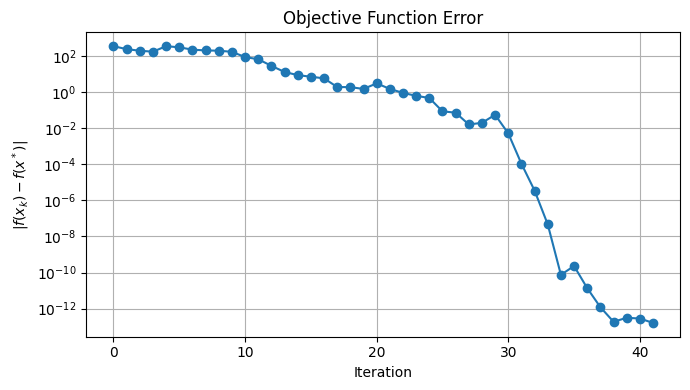

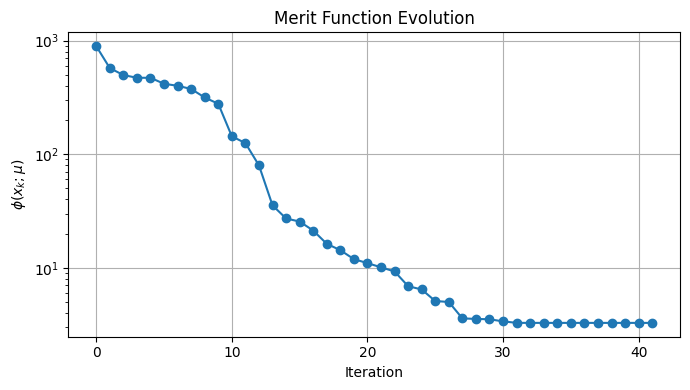

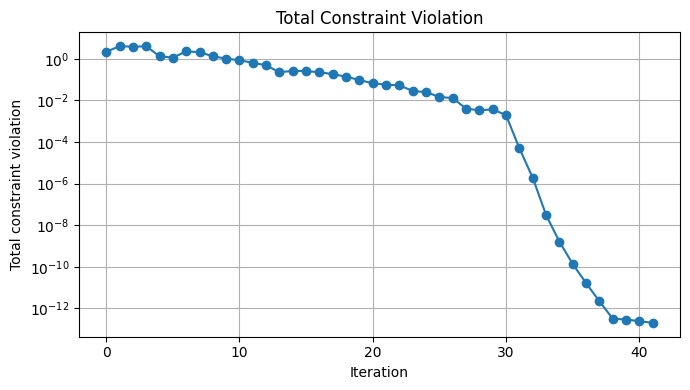

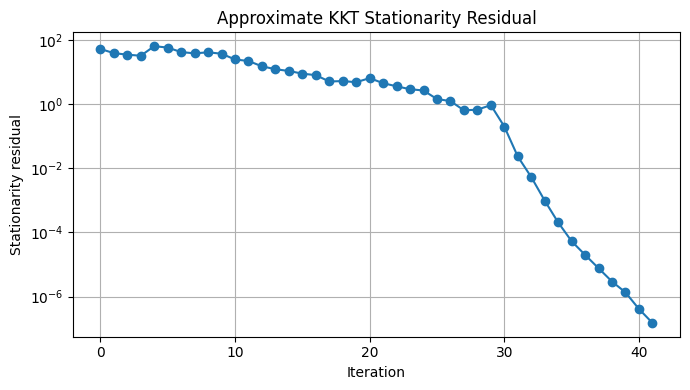

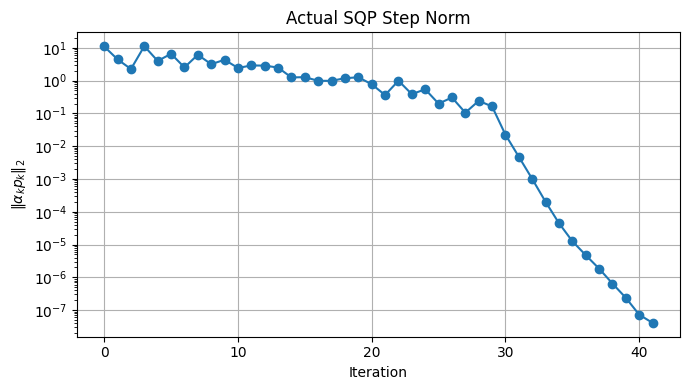

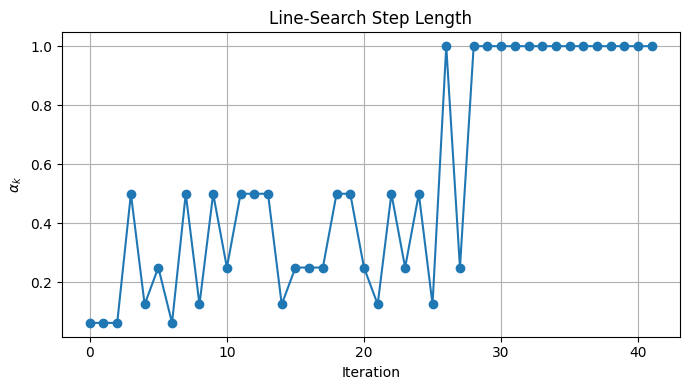

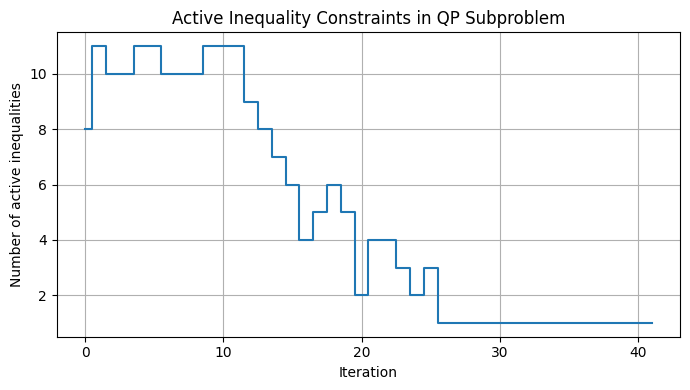

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(10)

#line rearch technique
#διαστάσεις

n = 24
me = 6
mi = 12

#πίνακας G
G = np.diag(6.0 * np.ones(n))

for k, val in [(1, -1.0), (2, -0.35), (3, -0.12)]:
    for i in range(n - k):
        G[i, i + k] = val
        G[i + k, i] = val



# Objective target point
x_c = 0.5 * np.ones(n)
rho = 0.03


# Objective function

def f(x):
    z = x - x_c
    return (
        0.5 * z @ G @ z
        + 0.25 * rho * np.sum((x - 0.2) ** 4)
        + 0.5 * np.sum(np.sin(x[:12]) ** 2)
    )


def grad_f(x):
    g = G @ (x - x_c)
    g += rho * (x - 0.2) ** 3
    g[:12] += np.sin(x[:12]) * np.cos(x[:12])
    return g


# μη γραμμικοί ισοτικοί περιορισμοί ceq(x) = 0
b_eq = np.array([0.15, 0.05, -0.05, -0.15, -0.25, -0.35])


def ceq(x):
    c = np.zeros(me)
    for i in range(me):
        c[i] = (
            x[i]
            + 0.90 * np.sin(x[i + 6])
            + 0.15 * x[i + 12] ** 2
            - 0.40 * np.cos(x[i + 18])
            - b_eq[i]
        )
    return c


def jac_eq(x):
    A = np.zeros((me, n))
    for i in range(me):
        A[i, i] = 1.0
        A[i, i + 6] = 0.90 * np.cos(x[i + 6])
        A[i, i + 12] = 0.30 * x[i + 12]
        A[i, i + 18] = 0.40 * np.sin(x[i + 18])
    return A


#μη γραμμικοί ανισοτικοί περιορισμοί cineq(x) >= 0

d_ineq = np.array([
    -0.65, -0.55, -0.45, -0.35,
    -0.25, -0.15, -0.05,  0.05,
     0.15,  0.25,  0.35,  0.45
])


def cineq(x):
    c = np.zeros(mi)
    for j in range(mi):
        c[j] = (
            x[j + 6]
            + 0.50 * np.sin(x[j % 6])
            + 0.10 * x[18 + (j % 6)] ** 2
            - d_ineq[j]
        )
    return c


def jac_ineq(x):
    A = np.zeros((mi, n))
    for j in range(mi):
        A[j, j + 6] = 1.0
        A[j, j % 6] = 0.50 * np.cos(x[j % 6])
        A[j, 18 + (j % 6)] = 0.20 * x[18 + (j % 6)]
    return A


#Violation and merit functions

def equality_violation(x):
    return np.linalg.norm(ceq(x), ord=np.inf)


def inequality_violation(x):
    return np.max(np.maximum(0.0, -cineq(x)))


def total_constraint_violation(x):
    return max(equality_violation(x), inequality_violation(x))


def merit(x, mu):
    return f(x) + mu * (
        np.sum(np.abs(ceq(x)))
        + np.sum(np.maximum(0.0, -cineq(x)))
    )



# Approximate KKT stationarity residual
def stationarity_residual(x):
    g = grad_f(x)
    Ae = jac_eq(x)
    Ai = jac_ineq(x)
    ci = cineq(x)

    active = ci <= 1e-4

    if np.any(active):
        J = np.column_stack([-Ae.T, -Ai[active].T])
    else:
        J = Ae.T

    multipliers, *_ = np.linalg.lstsq(J, -g, rcond=None)
    r = g + J @ multipliers

    return np.linalg.norm(r, ord=2)



#υποπρόβλημα

def solve_qp_subproblem(g, B, ce, Ae, ci, Ai):
    def q(p):
        return 0.5 * p @ B @ p + g @ p

    def grad_q(p):
        return B @ p + g

    constraints = []

    for i in range(me):
        constraints.append({
            "type": "eq",
            "fun": lambda p, i=i: Ae[i] @ p + ce[i],
            "jac": lambda p, i=i: Ae[i]
        })

    for j in range(mi):
        constraints.append({
            "type": "ineq",
            "fun": lambda p, j=j: Ai[j] @ p + ci[j],
            "jac": lambda p, j=j: Ai[j]
        })

    res = minimize(
        q,
        np.zeros(n),
        jac=grad_q,
        constraints=constraints,
        method="SLSQP",
        options={
            "ftol": 1e-12,
            "maxiter": 600,
            "disp": False
        }
    )

    return res



# SQP method with line-search

def sqp_method(max_iter=80, tol=1e-8):
    # Deliberately infeasible and distant initial point
    x = np.zeros(n)

    x[:8] = -3
    x[8:16] = 2.5
    x[16:] = -2

    B = 0.2 * np.eye(n)

    mu = 30.0
    eta = 1e-4
    tau = 0.5
    active_tol = 1e-3

    hist = {
        "objective": [],
        "merit": [],
        "total_violation": [],
        "stationarity": [],
        "step_norm": [],
        "alpha": [],
        "active_qp": [],
        "qp_success": []
    }

    for k in range(max_iter):
        g = grad_f(x)
        ce = ceq(x)
        ci = cineq(x)
        Ae = jac_eq(x)
        Ai = jac_ineq(x)

        qp_res = solve_qp_subproblem(g, B, ce, Ae, ci, Ai)
        p = qp_res.x

        phi0 = merit(x, mu)
        violation_l1 = np.sum(np.abs(ce)) + np.sum(np.maximum(0.0, -ci))

        dphi = g @ p - mu * violation_l1
        if dphi >= 0:
            dphi = -np.linalg.norm(p) ** 2 - violation_l1

        alpha = 1.0

        while merit(x + alpha * p, mu) > phi0 + eta * alpha * dphi:
            alpha *= tau
            if alpha < 1e-8:
                break

        x_new = x + alpha * p

        active_qp = np.sum(Ai @ p + ci <= active_tol)

        hist["objective"].append(f(x))
        hist["merit"].append(phi0)
        hist["total_violation"].append(total_constraint_violation(x))
        hist["stationarity"].append(stationarity_residual(x))
        hist["step_norm"].append(np.linalg.norm(alpha * p))
        hist["alpha"].append(alpha)
        hist["active_qp"].append(active_qp)
        hist["qp_success"].append(qp_res.success)

        # BFGS update
        s = x_new - x
        y = grad_f(x_new) - grad_f(x)
        Bs = B @ s

        if s @ y > 1e-8 and s @ Bs > 1e-14:
            B = B - np.outer(Bs, Bs) / (s @ Bs) + np.outer(y, y) / (s @ y)

        B = 0.5 * (B + B.T)

        eig_min = np.min(np.linalg.eigvalsh(B))
        if eig_min < 1e-6:
            B += (1e-6 - eig_min + 1e-6) * np.eye(n)

        x = x_new

        if total_constraint_violation(x) < tol and np.linalg.norm(alpha * p) < tol:
            break

    return x, hist



# Run SQP

x_sol, hist = sqp_method()

print("Final solution x:")
print(x_sol)

print("\nFinal objective value:")
print(f(x_sol))

print("\nFinal equality constraints ceq(x):")
print(ceq(x_sol))

print("\nFinal inequality constraints cineq(x):")
print(cineq(x_sol))

print("\nFinal total constraint violation:")
print(total_constraint_violation(x_sol))

print("\nFinal stationarity residual:")
print(stationarity_residual(x_sol))

print("\nNumber of SQP iterations:")
print(len(hist["objective"]))




plot_eps = 1e-16

# Remove final termination point from plots
plot_slice = slice(0, -1)

objective = np.array(hist["objective"])[plot_slice]
merit_values = np.array(hist["merit"])[plot_slice]
total_violation = np.array(hist["total_violation"])[plot_slice]
stationarity = np.array(hist["stationarity"])[plot_slice]
step_norm = np.array(hist["step_norm"])[plot_slice]
alpha_values = np.array(hist["alpha"])[plot_slice]
active_qp = np.array(hist["active_qp"])[plot_slice]

iters = np.arange(len(objective))

f_star = f(x_sol)
objective_error = np.abs(objective - f_star)
objective_error = np.maximum(objective_error, plot_eps)

merit_values = np.maximum(merit_values, plot_eps)
total_violation = np.maximum(total_violation, plot_eps)
stationarity = np.maximum(stationarity, plot_eps)
step_norm = np.maximum(step_norm, plot_eps)


#plots

#objective error
plt.figure(figsize=(7, 4))
plt.semilogy(iters, objective_error, marker="o")
plt.xlabel("Iteration")
plt.ylabel(r"$|f(x_k)-f(x^*)|$")
plt.title("Objective Function Error")
plt.grid(True)
plt.tight_layout()
plt.show()

#merit function
plt.figure(figsize=(7, 4))
plt.semilogy(iters, merit_values, marker="o")
plt.xlabel("Iteration")
plt.ylabel(r"$\phi(x_k;\mu)$")
plt.title("Merit Function Evolution")
plt.grid(True)
plt.tight_layout()
plt.show()

#total constraint violation
plt.figure(figsize=(7, 4))
plt.semilogy(iters, total_violation, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Total constraint violation")
plt.title("Total Constraint Violation")
plt.grid(True)
plt.tight_layout()
plt.show()

#approximate KKT residual
plt.figure(figsize=(7, 4))
plt.semilogy(iters, stationarity, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Stationarity residual")
plt.title("Approximate KKT Stationarity Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# actual SQP step norm
plt.figure(figsize=(7, 4))
plt.semilogy(iters, step_norm, marker="o")
plt.xlabel("Iteration")
plt.ylabel(r"$\|\alpha_k p_k\|_2$")
plt.title("Actual SQP Step Norm")
plt.grid(True)
plt.tight_layout()
plt.show()

#Line-search step length
plt.figure(figsize=(7, 4))
plt.plot(iters, alpha_values, marker="o")
plt.xlabel("Iteration")
plt.ylabel(r"$\alpha_k$")
plt.title("Line-Search Step Length")
plt.grid(True)
plt.tight_layout()
plt.show()

#active inequality constraints in QP
plt.figure(figsize=(7, 4))
plt.step(iters, active_qp, where="mid")
plt.xlabel("Iteration")
plt.ylabel("Number of active inequalities")
plt.title("Active Inequality Constraints in QP Subproblem")
plt.grid(True)
plt.tight_layout()
plt.show()

Iter   0: f =  3.46397781e+00, ||proj_grad|| =  1.016e+01, |A| = 0
Iter   1: f = -3.43661626e+01, ||proj_grad|| =  1.302e+01, |A| = 87
Iter   2: f = -6.25712893e+01, ||proj_grad|| =  3.763e+00, |A| = 4
Iter   3: f = -6.39832797e+01, ||proj_grad|| =  2.792e+00, |A| = 0
Iter   4: f = -6.45653085e+01, ||proj_grad|| =  7.180e-01, |A| = 0
Iter   5: f = -6.46018929e+01, ||proj_grad|| =  6.707e-02, |A| = 0
Iter   6: f = -6.46022403e+01, ||proj_grad|| =  1.412e-02, |A| = 0
Iter   7: f = -6.46022610e+01, ||proj_grad|| =  5.068e-03, |A| = 0
Iter   8: f = -6.46022643e+01, ||proj_grad|| =  1.063e-03, |A| = 0
Iter   9: f = -6.46022645e+01, ||proj_grad|| =  3.623e-04, |A| = 0
Iter  10: f = -6.46022645e+01, ||proj_grad|| =  3.364e-04, |A| = 0
Iter  11: f = -6.46022645e+01, ||proj_grad|| =  9.879e-05, |A| = 0
Iter  12: f = -6.46022645e+01, ||proj_grad|| =  8.913e-06, |A| = 0

Σύγκλιση στο iteration 12.

ΒΑΣΙΚΑ ΧΑΡΑΚΤΗΡΙΣΤΙΚΑ
n = 120
Ελάχιστη ιδιοτιμή του G = 2.90263265e+00
Μέγιστη ιδιοτιμή του G = 7.4

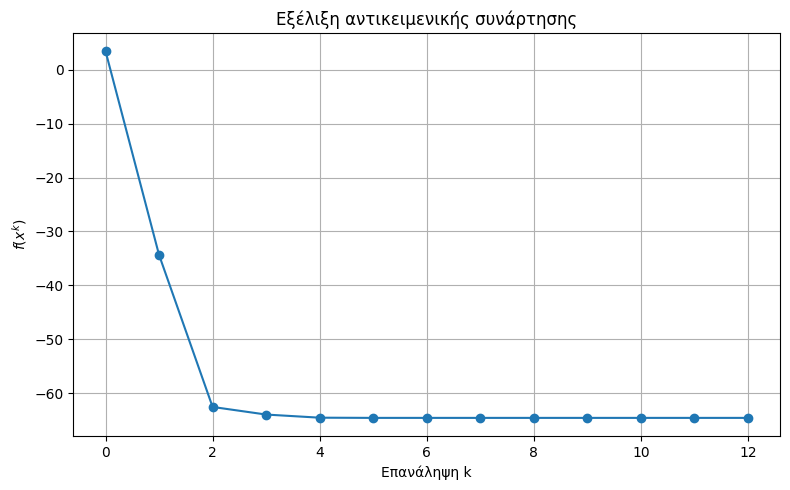

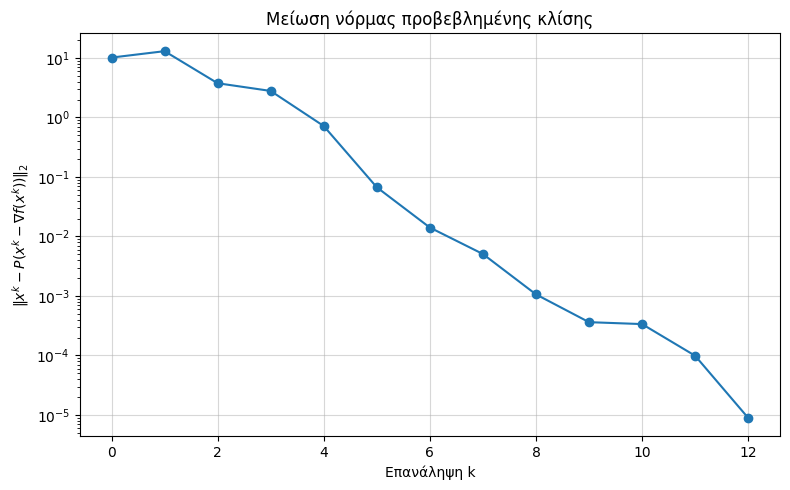

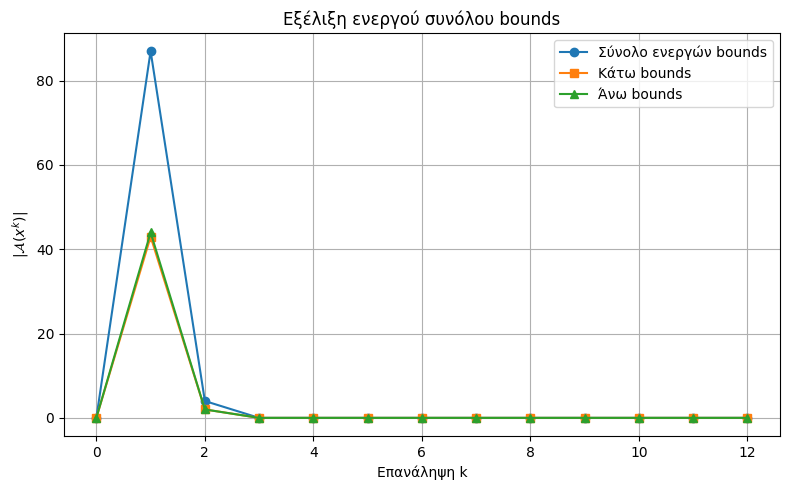

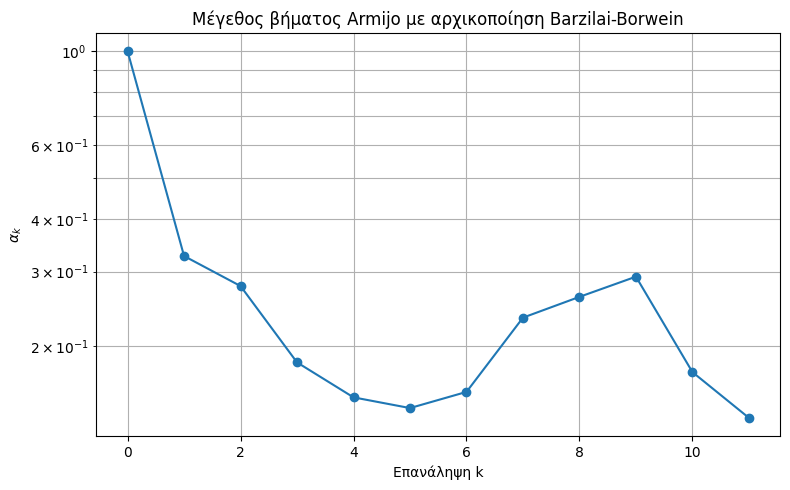

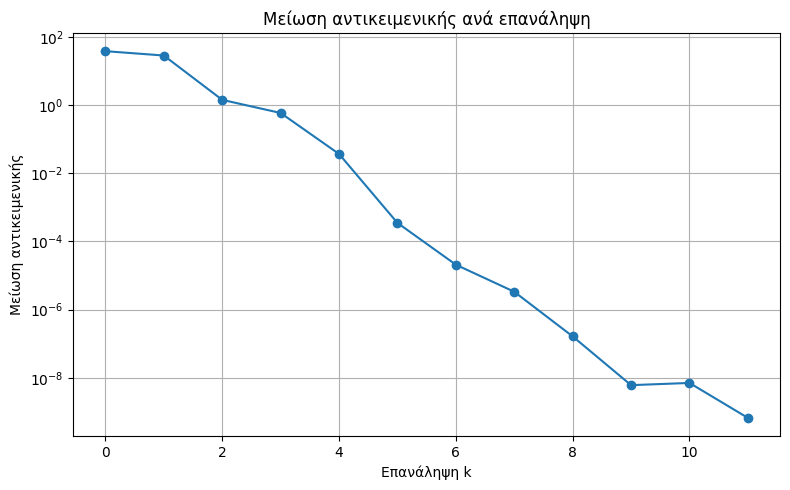

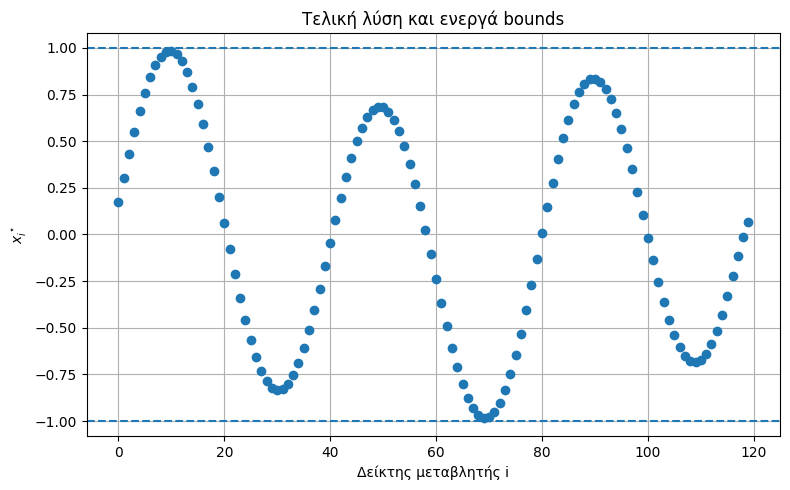

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Μέθοδος Προβεβλημένων Κλίσεων

#πίνακας G
def build_spd_matrix(n):
    G = np.zeros((n, n))

    for i in range(n):
        G[i, i] = 6.0

        if i + 1 < n:
            G[i, i + 1] = -1.0
            G[i + 1, i] = -1.0

        if i + 2 < n:
            G[i, i + 2] = -0.4
            G[i + 2, i] = -0.4

        if i + 3 < n:
            G[i, i + 3] = -0.15
            G[i + 3, i] = -0.15

    return G


def f_value(x, G, c):
    return 0.5 * x @ G @ x - c @ x


def grad_f(x, G, c):
    return G @ x - c


def project_bounds(x, l, u):
    return np.minimum(np.maximum(x, l), u)


def projected_gradient_norm(x, G, c, l, u):
    g = grad_f(x, G, c)
    xp = project_bounds(x - g, l, u)
    return np.linalg.norm(x - xp)


def active_set_info(x, l, u, tol=1e-10):
    active_lower = np.abs(x - l) <= tol
    active_upper = np.abs(x - u) <= tol
    active = active_lower | active_upper

    return {
        "active_total": np.sum(active),
        "active_lower": np.sum(active_lower),
        "active_upper": np.sum(active_upper),
    }


def projected_gradient_method(
    G, c, l, u, x0,
    max_iter=300,
    tol=1e-5,
    alpha0=1.0,
    beta=0.5,
    sigma=1e-4,
    stagnation_tol=1e-12
):
    x = project_bounds(x0, l, u)

    f_hist = []
    pg_hist = []
    active_hist = []
    active_lower_hist = []
    active_upper_hist = []
    alpha_hist = []
    decrease_hist = []

    x_prev = None
    g_prev = None
    alpha_bb = alpha0

    for k in range(max_iter):
        f_k = f_value(x, G, c)
        g = grad_f(x, G, c)

        pg_norm = projected_gradient_norm(x, G, c, l, u)
        active_info = active_set_info(x, l, u)

        f_hist.append(f_k)
        pg_hist.append(pg_norm)
        active_hist.append(active_info["active_total"])
        active_lower_hist.append(active_info["active_lower"])
        active_upper_hist.append(active_info["active_upper"])

        print(
            f"Iter {k:3d}: f = {f_k: .8e}, "
            f"||proj_grad|| = {pg_norm: .3e}, "
            f"|A| = {active_info['active_total']}"
        )

        if pg_norm < tol:
            print(f"\nΣύγκλιση στο iteration {k}.")
            break

        if k > 5 and abs(f_hist[-1] - f_hist[-2]) < stagnation_tol:
            print(f"\nΣτάση λόγω numerical stagnation στο iteration {k}.")
            break

        # Barzilai-Borwein αρχικοποίηση του βήματος
        if k > 0:
            s = x - x_prev
            y = g - g_prev
            sy = s @ y

            if sy > 0:
                alpha_bb = (s @ s) / sy

        alpha = alpha_bb

        # Armijo backtracking line search με προβολή
        while True:
            x_trial = project_bounds(x - alpha * g, l, u)
            d = x_trial - x
            f_trial = f_value(x_trial, G, c)

            if f_trial <= f_k + sigma * g @ d:
                break

            alpha *= beta

            if alpha < 1e-14:
                break

        decrease = f_k - f_trial

        alpha_hist.append(alpha)
        decrease_hist.append(decrease)

        x_prev = x.copy()
        g_prev = g.copy()
        x = x_trial.copy()

    results = {
        "x": x,
        "f_hist": np.array(f_hist),
        "pg_hist": np.array(pg_hist),
        "active_hist": np.array(active_hist),
        "active_lower_hist": np.array(active_lower_hist),
        "active_upper_hist": np.array(active_upper_hist),
        "alpha_hist": np.array(alpha_hist),
        "decrease_hist": np.array(decrease_hist),
        "iterations": len(f_hist) - 1
    }

    return results


#διαστάσεις

n = 120

G = build_spd_matrix(n)

l = -np.ones(n)
u = np.ones(n)

# Ντετερμινιστικός ορισμός του c και του αρχικού σημείου x0
t = np.linspace(0, 1, n)

c = 2.5 * np.sin(6 * np.pi * t) + 0.5 * np.cos(2 * np.pi * t)

x0 = 0.2 * np.sin(2 * np.pi * t)

results = projected_gradient_method(
    G, c, l, u, x0,
    max_iter=300,
    tol=1e-5,
    alpha0=1.0,
    beta=0.5,
    sigma=1e-4,
    stagnation_tol=1e-12
)

x_star = results["x"]
f_hist = results["f_hist"]
pg_hist = results["pg_hist"]
active_hist = results["active_hist"]
active_lower_hist = results["active_lower_hist"]
active_upper_hist = results["active_upper_hist"]
alpha_hist = results["alpha_hist"]
decrease_hist = results["decrease_hist"]


#Βασικά χαρακτηριστικά
eigvals = np.linalg.eigvalsh(G)
lambda_min = eigvals[0]
lambda_max = eigvals[-1]
cond_G = lambda_max / lambda_min

final_active_info = active_set_info(x_star, l, u)

print("\n==============================")
print("ΒΑΣΙΚΑ ΧΑΡΑΚΤΗΡΙΣΤΙΚΑ")
print("==============================")
print(f"n = {n}")
print(f"Ελάχιστη ιδιοτιμή του G = {lambda_min:.8e}")
print(f"Μέγιστη ιδιοτιμή του G = {lambda_max:.8e}")
print(f"κ₂(G) = {cond_G:.8e}")

print("\n==============================")
print("ΑΠΟΤΕΛΕΣΜΑΤΑ ΠΡΟΒΕΒΛΗΜΕΝΩΝ ΚΛΙΣΕΩΝ")
print("==============================")
print(f"Αριθμός επαναλήψεων = {results['iterations']}")
print(f"Τελική τιμή f(x*) = {f_value(x_star, G, c):.8e}")
print(f"Projected gradient norm = {projected_gradient_norm(x_star, G, c, l, u):.8e}")
print(f"Πλήθος ενεργών bounds = {final_active_info['active_total']}")
print(f"Ενεργά κάτω bounds = {final_active_info['active_lower']}")
print(f"Ενεργά άνω bounds = {final_active_info['active_upper']}")
print(f"min(x* - l) = {np.min(x_star - l):.8e}")
print(f"min(u - x*) = {np.min(u - x_star):.8e}")

print("\nΠρώτες 10 συνιστώσες του x*:")
print(np.round(x_star[:10], 6))


#plots

iterations = np.arange(len(f_hist))

plt.figure(figsize=(8, 5))
plt.plot(iterations, f_hist, marker="o")
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$f(x^k)$")
plt.title("Εξέλιξη αντικειμενικής συνάρτησης")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogy(iterations, pg_hist, marker="o")
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$\|x^k - P(x^k - \nabla f(x^k))\|_2$")
plt.title("Μείωση νόρμας προβεβλημένης κλίσης")
plt.grid(True, which="major", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(iterations, active_hist, marker="o", label="Σύνολο ενεργών bounds")
plt.plot(iterations, active_lower_hist, marker="s", label="Κάτω bounds")
plt.plot(iterations, active_upper_hist, marker="^", label="Άνω bounds")
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$|\mathcal{A}(x^k)|$")
plt.title("Εξέλιξη ενεργού συνόλου bounds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogy(np.arange(len(alpha_hist)), alpha_hist, marker="o")
plt.xlabel("Επανάληψη k")
plt.ylabel(r"$\alpha_k$")
plt.title("Μέγεθος βήματος Armijo με αρχικοποίηση Barzilai-Borwein")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogy(np.arange(len(decrease_hist)), decrease_hist, marker="o")
plt.xlabel("Επανάληψη k")
plt.ylabel("Μείωση αντικειμενικής")
plt.title("Μείωση αντικειμενικής ανά επανάληψη")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x_star, marker="o", linestyle="none")
plt.axhline(1.0, linestyle="--")
plt.axhline(-1.0, linestyle="--")
plt.xlabel("Δείκτης μεταβλητής i")
plt.ylabel(r"$x_i^\star$")
plt.title("Τελική λύση και ενεργά bounds")
plt.grid(True)
plt.tight_layout()
plt.show()